# ML from DFT data

- [ ] learn on separated FM and NM AGAIN
- [ ] remove high order BOP features before learing
- [X] Recursive Feature elimination after removing high order features
- [ ] make recursion on bond energy
- [X] change OS to 1/10,
- [ ] 1/10 OS and scf bop
- learn form library features
- compare different regression methods
   - Linear regression
   - add SVM
   - kernel methods
   - Gaussian process.
- compare different test-train splittings
- Learn on increasing domain knowledge

 - input: clean features dataframes from pickles
 - output : plots and Models

In [1]:
from Tools.DatasetTools.Commoms import *

In [2]:
plt.rc('figure', figsize=(18, 8))
plt.rc('font', size=22)
from matplotlib.lines import Line2D

# Parameters 

In [3]:
from Tools.DatasetTools.DatasetOperator import Dataset, DatasetTester

In [4]:
DS = Dataset('Fe-Mo')

In [5]:
ModelName = 'Kernel Ridge'

# Targets

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


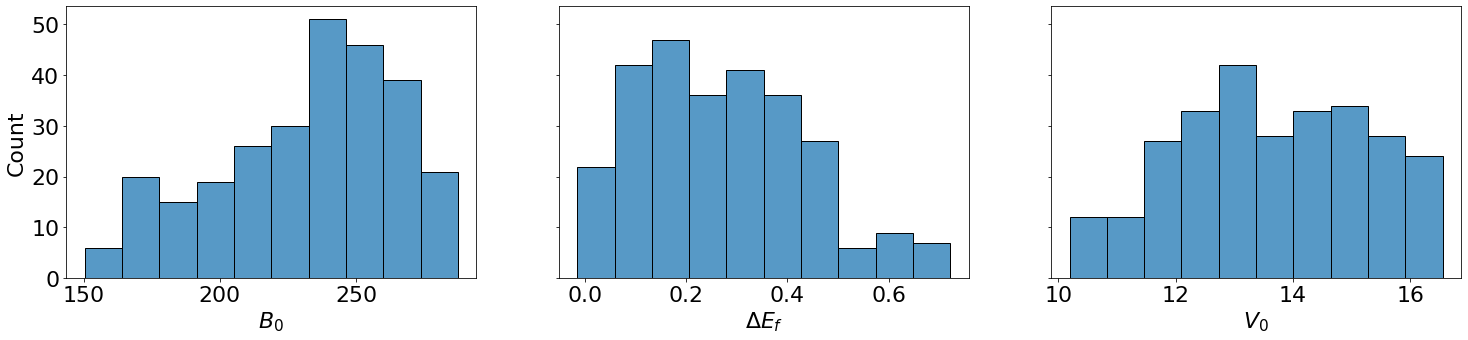

In [6]:
fig, ax = plt.subplots(1,3, figsize=(25, 5), sharey = True)
sns.histplot( DS.BS['B0'], ax= ax[0])
sns.histplot( DS.BS['EF'], ax= ax[1])
sns.histplot( DS.BS['V0'], ax= ax[2])
ax[0].set_xlabel('$B_0$')
ax[1].set_xlabel('$\Delta E_f$')
ax[2].set_xlabel('$V_0$')
fig.savefig(f'{DS.dataset}/graphs/{DS.dataset}_target_distributions.eps')

# Machine Learning 

In [7]:
from Tools.DatasetTools.MLConveniences import *

In [8]:
resultslocation = DS.resultslocation

## Feature sets

In [9]:
Features = DS.Features  # {name: pd.read_pickle(filename) for name, filename in DescriptorFileList.items()}

In [10]:
Features['Canonical BOP']

,Structure,Mag,U_bind,U_bond_atom_list_1_0,U_bond_atom_list_1_CN12,U_bond_atom_list_1_CN13,U_bond_atom_list_1_CN14,U_bond_atom_list_1_CN15,U_bond_atom_list_1_CN16,moments_1_0,...,Binf_1_CN14,Binf_1_CN15,Binf_1_CN16,sf_0,sf_CN12,sf_CN13,sf_CN14,sf_CN15,sf_CN16,random
Fe_pv8Mo_sv22.sigma-BBABB.FM,10,0,-100.702297,-7.906327,-1.428383,0.000000,-6.005237,-0.472706,0.000000,1.174563,...,0.660966,0.164368,0.000000,1.224171,1.311938,0.000000,1.187302,1.155462,0.000000,0.347997
Fe_pv10Mo_sv20.sigma-ABBAB.FM,10,0,-78.594335,-7.771059,-1.424594,0.000000,-5.906606,-0.439859,0.000000,1.201761,...,0.668575,0.166260,0.000000,1.224174,1.311938,0.000000,1.187308,1.155463,0.000000,0.893088
Fe_pv4Mo_sv20.C36-ABBBB.FM,3,0,-94.449166,-8.534487,-7.595698,0.000000,0.000000,0.000000,-0.938789,1.303069,...,0.000000,0.000000,0.501537,1.081732,1.156282,0.000000,0.000000,0.000000,0.901327,0.317718
Fe_pv5Mo_sv24.chi-AABB.FM,6,0,-116.205661,-8.244366,-6.070495,-1.652565,0.000000,0.000000,-0.521305,1.162619,...,0.000000,0.000000,0.186186,1.251703,1.437268,1.179083,0.000000,0.000000,1.006205,0.284068
Fe_pv15Mo_sv38.R-AAAABBBBBBB.NM,4,1,-121.105805,-8.136275,-2.533063,0.000000,-0.844603,-0.318349,-4.440260,1.218738,...,0.256809,0.124851,0.170809,1.192249,1.343509,0.000000,1.139857,0.956735,0.947607,0.115668
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Fe_pv3Mo_sv10.mu-ABBBA.NM,9,1,-40.035290,-8.020136,-2.520056,0.000000,-0.663807,-0.397166,-4.439107,1.265062,...,0.220371,0.224323,0.222761,1.071111,1.222567,0.000000,0.902499,0.748344,1.001884,0.025283
Fe_pv8Mo_sv22.sigma-BBABB.NM,10,1,-100.702297,-7.906327,-1.428383,0.000000,-6.005237,-0.472706,0.000000,1.174563,...,0.660966,0.164368,0.000000,1.224171,1.311938,0.000000,1.187302,1.155462,0.000000,0.503552
Fe_pv1Mo_sv3.L12-AB3.FM,7,0,-12.617373,-6.832601,-6.832601,0.000000,0.000000,0.000000,0.000000,1.063750,...,0.000000,0.000000,0.000000,1.140024,1.140024,0.000000,0.000000,0.000000,0.000000,0.678407
Fe_pv8Mo_sv22.sigma-BBBBA.FM,10,0,-94.569986,-7.892530,-5.305761,0.000000,-2.136368,-0.450401,0.000000,1.174563,...,0.660966,0.164368,0.000000,1.224171,1.311938,0.000000,1.187302,1.155462,0.000000,0.542701


In [11]:
Features.keys()

dict_keys(['atomic', 'dataset', 'Pyscal', 'Canonical BOP', 'Projections BOP', 'Projections OS BOP', 'Projections sOS BOP', 'dataset + Canonical BOP', 'dataset + Projections BOP', 'dataset + Projections OS BOP', 'dataset + Projections sOS BOP'])

## BOP features with and without CP averages

In [12]:
def clean_CNAVS(name:str, features:pd.core.frame.DataFrame):
    if 'BOP' in name:
        return features.filter(regex='^(?!.*_CN)')
    else:
        return features

In [13]:
def clean_zeros(name:str, features:pd.core.frame.DataFrame):
    if 'BOP' in name:
        return features.filter(regex='^(?!.*_0$)')
    else:
        return features

In [14]:
def notyetclean(name:str):
    return ('BOP' in name) and ('CNAV' not in name) and ('Zeros' not in name)

In [15]:
Features.update({name+' no CNAV': clean_CNAVS(name, features) for name, features in Features.items() if notyetclean(name) } )

In [16]:
# Features.update({name+' no Zeros': clean_zeros(name, features) for name, features in Features.items() if notyetclean(name)} )

## test - train splits

In [17]:
samplesplit = DS.get_samplesplit()

# Models: adjust params

In [18]:
Models = {
    ModelName: Pipeline([('scaler', StandardScaler()), ('regressor', KernelRidge())]),
}

In [19]:
from importlib.machinery import SourceFileLoader
MO = SourceFileLoader('MO', 'Tools/DatasetTools/ModelSelection.py').load_module().ModelOptions(DS.dataset)

In [20]:
MO.load_model_options(ModelName)

In [21]:
MO.modeloptions[ModelName]

{'regressor__alpha': [0.1, 0.01, 0.001, 0.0001],
 'regressor__kernel': ['rbf', 'polynomial'],
 'regressor__degree': [4, 5, 6, 7],
 'regressor__coef0': [0, 1, 10]}

In [22]:
samplefolds = list(DS.get_folds())

# fits

In [23]:
fittedmodelslocation = os.path.join(DS.resultslocation, f'{ModelName}_FittedCVSearch.pkl')

if os.path.exists(fittedmodelslocation):
    with open(fittedmodelslocation, 'rb') as pkl:
        FittedModels = pickle.load(pkl)
else:
    FittedModels = {}

In [24]:
for name, model in Models.items():
    print (name)
    progress = tqdm(Features.items())
    for key, features in progress: #Features.items():
        if 'no CNAV' in key:
            continue
        if (name, key) in FittedModels.keys():
            continue
        model = GridSearchCV(
            Models[name],
            MO.modeloptions[name], 
            scoring='neg_root_mean_squared_error', 
            cv = samplefolds,
            verbose = 1,
            return_train_score= True,
        )
        FittedModels[(name, key)] = model.fit(features, DS.target)

Kernel Ridge


  0%|          | 0/19 [00:00<?, ?it/s]

In [25]:
with open(fittedmodelslocation, 'wb') as pkl:
    pickle.dump(FittedModels, pkl)

In [26]:
best_scores = collect_best_scores(FittedModels)

In [27]:
best_combi = best_scores.idxmin()['test']

In [28]:
best_combi

('Kernel Ridge', 'dataset + Projections OS BOP')

In [29]:
results = pd.DataFrame.from_dict(FittedModels[best_combi].cv_results_)

In [30]:
results.sort_values(by='mean_test_score', ascending=False, inplace=True)

In [31]:
best_scores.loc[best_combi]

test     3.754478e-02
train    1.172306e-09
Name: (Kernel Ridge, dataset + Projections OS BOP), dtype: float64

In [32]:
results.loc[7].params

{'regressor__alpha': 0.1,
 'regressor__coef0': 0,
 'regressor__degree': 7,
 'regressor__kernel': 'polynomial'}

In [33]:
for parameters in MO.modeloptions.values():
    for key in parameters.keys():
        print (results.groupby(by='param_'+key)['mean_test_score'].max())

param_regressor__alpha
0.0001   -0.039906
0.0010   -0.039769
0.0100   -0.038907
0.1000   -0.037545
Name: mean_test_score, dtype: float64
param_regressor__kernel
polynomial   -0.037545
rbf          -0.058906
Name: mean_test_score, dtype: float64
param_regressor__degree
4   -0.038399
5   -0.037545
6   -0.037781
7   -0.038832
Name: mean_test_score, dtype: float64
param_regressor__coef0
0    -0.058906
1    -0.037545
10   -0.055817
Name: mean_test_score, dtype: float64


In [34]:
FittedModels[best_combi].best_params_

{'regressor__alpha': 0.1,
 'regressor__coef0': 1,
 'regressor__degree': 5,
 'regressor__kernel': 'polynomial'}

In [35]:
best_scores

test         train
Kernel Ridge dataset + Projections OS BOP   0.037545  1.172306e-09
             Projections OS BOP             0.039825  1.859932e-09
             Projections BOP                0.041779  1.240513e-09
             dataset + Projections BOP      0.041785  7.754922e-10
             dataset + Projections sOS BOP  0.043752  7.536837e-10
             Projections sOS BOP            0.044007  1.255306e-09
             dataset + Canonical BOP        0.051604  1.129929e-07
             dataset                        0.068299  5.488850e-10
             Canonical BOP                  0.074696  2.066981e-03
             atomic                         0.169936  8.675813e-02
             Pyscal                         0.170475  1.170729e-01

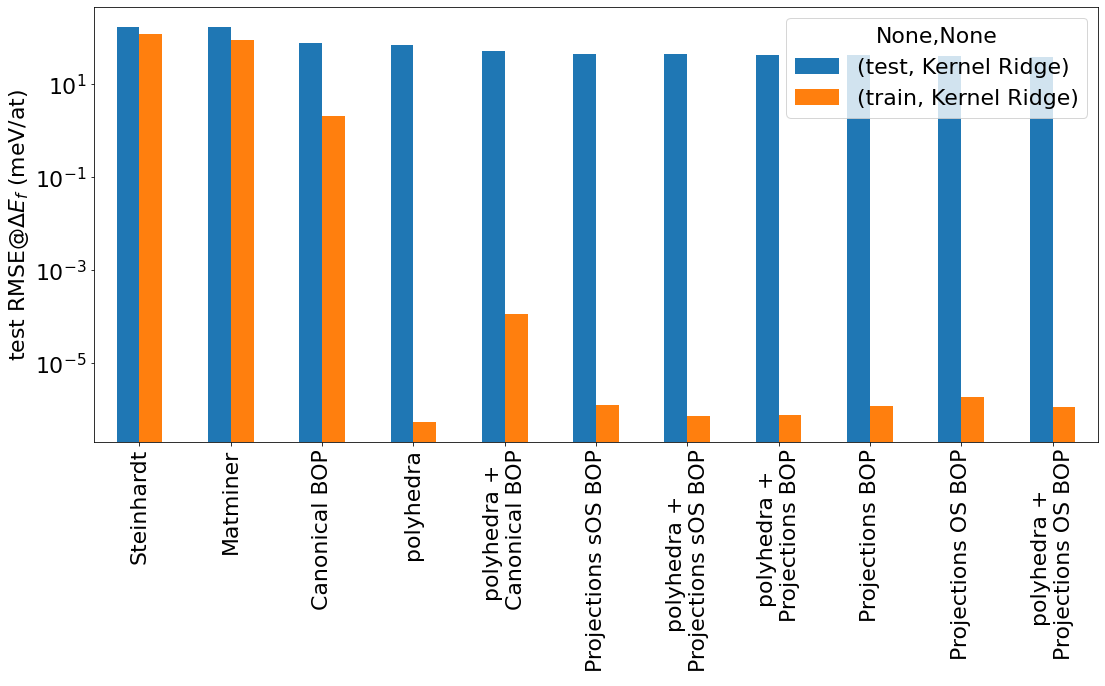

In [36]:
ax = plot_best_scores(best_scores)

# Prediction line 

In [37]:
Prediction = {fname: model.predict(features) for (fname, features), model in zip(Features.items(),FittedModels.values())}

In [38]:
#iwanttoplot = {'atomic':'Matminer',
iwanttoplot = {'Canonical BOP':'Canonical BOP',  best_combi[1]: best_combi[1]}

In [39]:
pallete = sns.color_palette('magma_r', n_colors=len(iwanttoplot))

In [40]:
x_y = np.linspace(DS.target.min()-0.1, DS.target.max()+0.1, 2)

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


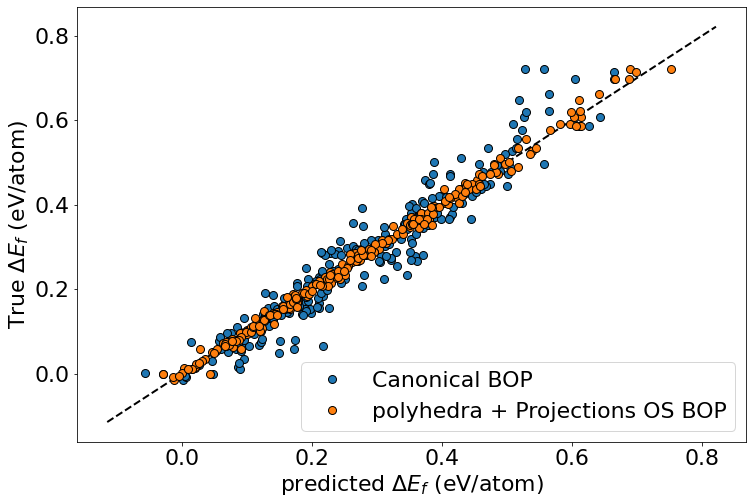

In [41]:
fig, ax = plt.subplots(figsize=(12,8))
ax.plot(x_y, x_y, '--k', lw=2)
for (name, legend), color in zip(iwanttoplot.items(), pallete):
    legend = legend.replace('dataset', 'polyhedra')
    ax.plot(Prediction[name], DS.target, 'o', markersize=8, markeredgecolor='k', label=legend)
#    sns.scatterplot(Prediction[name], DS.target,ax=ax) #, markersize=8, markeredgecolor='k',  color = color, label=legend)
ax.set_xlabel(r'predicted $\Delta E_f$ (eV/atom)')
ax.set_ylabel(r'True $\Delta E_f$ (eV/atom)')
ax.legend()
fig.savefig(os.path.join(DS.dataset,'graphs', f'{DS.dataset}_{ModelName}_predictionline.eps'))

# Recursivity

In [42]:
Tester = DatasetTester()

In [43]:
from importlib.machinery import SourceFileLoader
Tester = SourceFileLoader('Tester', 'Tools/DatasetTools/DatasetOperator.py').load_module().DatasetTester()
#from Tools.DatasetTools.DatasetOperator import Dataset
#DS = SourceFileLoader('DS', 'Tools/DatasetTools/DatasetOperator.py').load_module().Dataset('Fe-Mo')
#Tester = SourceFileLoader('Tester', 'Tools/DatasetTools/DatasetOperator.py').load_module().DatasetTester()
#samplesplit = DS.get_samplesplit()

In [44]:
import copy

In [45]:
RecursivityModels = copy.deepcopy(FittedModels)

In [46]:
test_scores = Tester.make_recursivity_anbn(DS, RecursivityModels, {'includemag':False})

  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

Tools/DatasetTools/DatasetOperator.py:219: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o-" (-> marker='o'). The keyword argument will take precedence.
  axes.plot(


(<Figure size 1296x576 with 1 Axes>,
 <AxesSubplot:xlabel='number of features', ylabel='test RMSE @ $\\Delta E_f$'>)

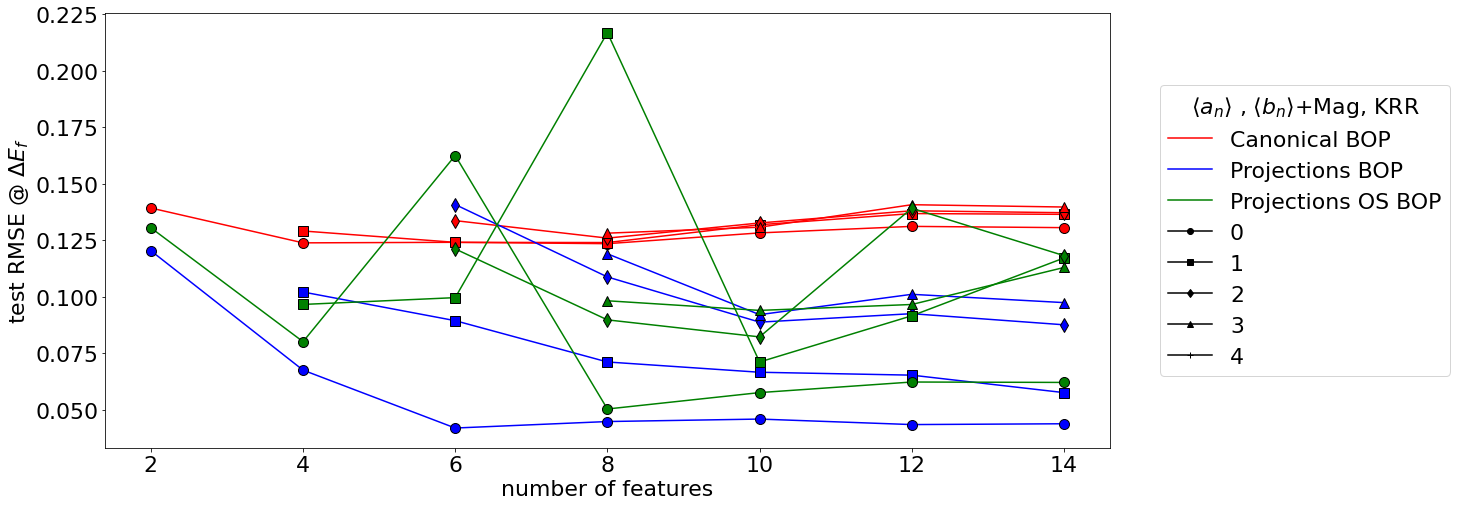

In [47]:
Tester.plot_recursivity_curve(test_scores, ModelName, )

In [48]:
fig.savefig(f'{DS.dataset}/graphs/{DS.dataset}_{ModelName}_recursivity_anbn.pdf', bbox_inches='tight')

# Fits on reduced features 

In [49]:
ReducedFittedModels = {}

In [50]:
Reduced_features_fitting_location = os.path.join(DS.resultslocation, 'ReducedFeaturesCVSearch.pkl')

In [51]:
if os.path.exists(Reduced_features_fitting_location):
    with open(Reduced_features_fitting_location, 'rb') as pkl:
        ReducedFittedModels = pickle.load(pkl)

In [52]:
maxorders = [8,10,12,14,16]
for name, model in Models.items():
    progress = tqdm(product(Features.items(), maxorders), total=len(maxorders)*len(Features))
    for (key, features), maxorder in progress:  #maxorder in range(4,9):
        progress.set_description(name+', '+key+', '+str(maxorder)+':  ')
        if 'no CNAV' in key:
            continue
        if 'BOP' not in key:
            continue
        if 'Projections' not in key:
            continue
        if (name, key, maxorder) in ReducedFittedModels.keys():
            continue
        if maxorder < 10:
            regexstr = f'^(?!.*_[{maxorder}-9]_.*|.*_1[0-9]_.*)'
        else:
            regexstr = f'^(?!.*_1[{maxorder - 10}-9]_.*)'
#        for key, features in progress: #Features.items():
        model = GridSearchCV(
            Models[name],
            MO.modeloptions[name], 
            scoring='neg_root_mean_squared_error', 
            cv = samplefolds,
            return_train_score= True,
        )
        if 'BOP' in key :
            reducedfeatures = features.filter(regex=regexstr)
        else:
            reducedfeatures = features
        ReducedFittedModels[(name, key, maxorder)] = model.fit(reducedfeatures, DS.target)

  0%|          | 0/95 [00:00<?, ?it/s]

In [53]:
with open(Reduced_features_fitting_location, 'wb') as pkl:
    pickle.dump(ReducedFittedModels, pkl)

In [54]:
best_combi 

('Kernel Ridge', 'dataset + Projections OS BOP')

In [55]:
somecombi = (ModelName, 'Projections BOP')

In [56]:
features_in_reduced = pd.Index(ReducedFittedModels[somecombi+(16,)].feature_names_in_)

In [57]:
features_in = pd.Index(FittedModels[somecombi].feature_names_in_)

In [58]:
features_in.difference(features_in_reduced)

Index([], dtype='object')

In [59]:
best_scores_reduced = collect_best_scores(ReducedFittedModels)

In [60]:
model = best_scores_reduced.index.get_level_values(0)

In [61]:
test_scores_vs_max = best_scores_reduced.unstack().transpose().loc['test'].dropna(axis=1)

In [62]:
test_scores_vs_max[ModelName]

,Projections BOP,Projections OS BOP,Projections sOS BOP,dataset + Projections BOP,dataset + Projections OS BOP,dataset + Projections sOS BOP
8,0.043581,0.041993,0.044696,0.044659,0.038915,0.044382
10,0.041206,0.041496,0.041450,0.041953,0.037851,0.041795
12,0.040112,0.041260,0.040487,0.040557,0.037546,0.040613
14,0.040098,0.040107,0.041476,0.040365,0.037581,0.041540
16,0.041515,0.038976,0.043131,0.041499,0.037639,0.043047


In [63]:
full_model_test_scores = best_scores.unstack().transpose().loc['test']

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


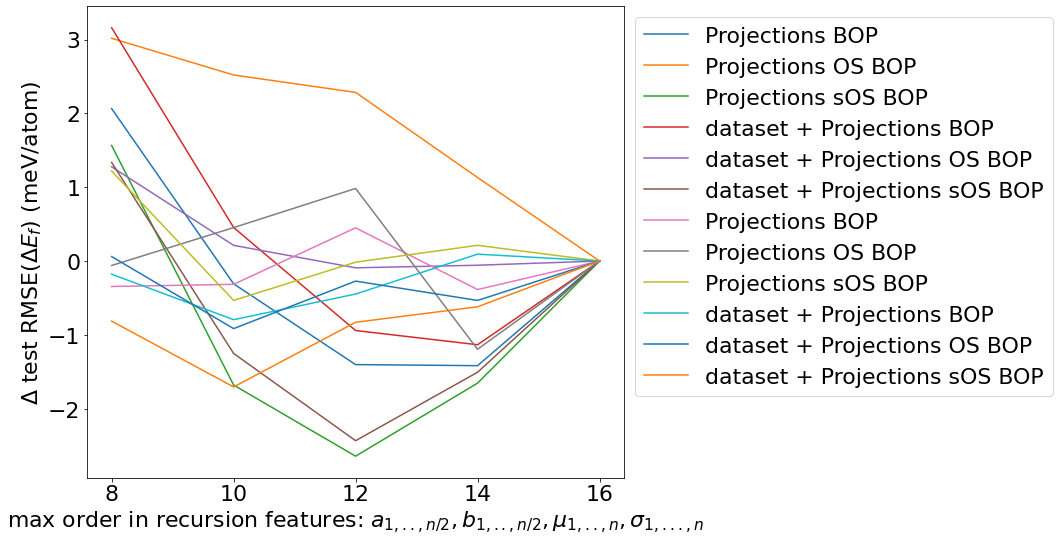

In [64]:
fig, ax = plt.subplots(figsize=(15,8))
for combi in test_scores_vs_max.columns:
#    if 'BOP' not in combi[1]:
#        continue
#    if 'Canonical' in combi[1]:
#        continue
#    if 'dataset' not in combi[1]:
#        continue
    drmse = (test_scores_vs_max[combi].values -test_scores_vs_max[combi].values[-1])*1000 #- full_model_test_scores[combi[0]][combi[1]]*1000
    l = ax.plot(test_scores_vs_max[combi].index,drmse , label=combi[1])[0]
#    ax.axhline(full_model_test_scores[combi[0]][combi[1]]*1000,ls='--', color=l.get_color())
ax.legend(bbox_to_anchor = (1,1))
ax.set_ylabel(r'$\Delta$ test RMSE($\Delta E_f$) (meV/atom)')
ax.set_xlabel(r'max order in recursion features: $a_{1,..,n/2}, b_{1,..,n/2}, \mu_{1,..,n}, \sigma_{1,...,n}$')
fig.tight_layout()
fig.savefig(os.path.join(DS.dataset, 'graphs', f'{DS.dataset}_full_recursivity.eps'))

# Feature Importances 

In [66]:
importances = {}
for (modelname, name), estimator in FittedModels.items():
    print(name)
    allimportances = get_importances(estimator.best_estimator_ , DS.Features[name], DS.target)
    importances[(modelname, name)] =allimportances[allimportances['importances_mean']>=allimportances['importances_mean']['random']]

atomic
dataset
Pyscal
Canonical BOP
Projections BOP
Projections OS BOP
Projections sOS BOP
dataset + Canonical BOP
dataset + Projections BOP
dataset + Projections OS BOP
dataset + Projections sOS BOP


In [67]:
for (modelname, name),timportances in importances.items():
    timportances.sort_values(by='importances_mean', inplace=True, ascending=False)

/tmp/ipykernel_24897/281972631.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  timportances.sort_values(by='importances_mean', inplace=True, ascending=False)


In [68]:
from Tools.DatasetTools.Tools import get_str_formatted

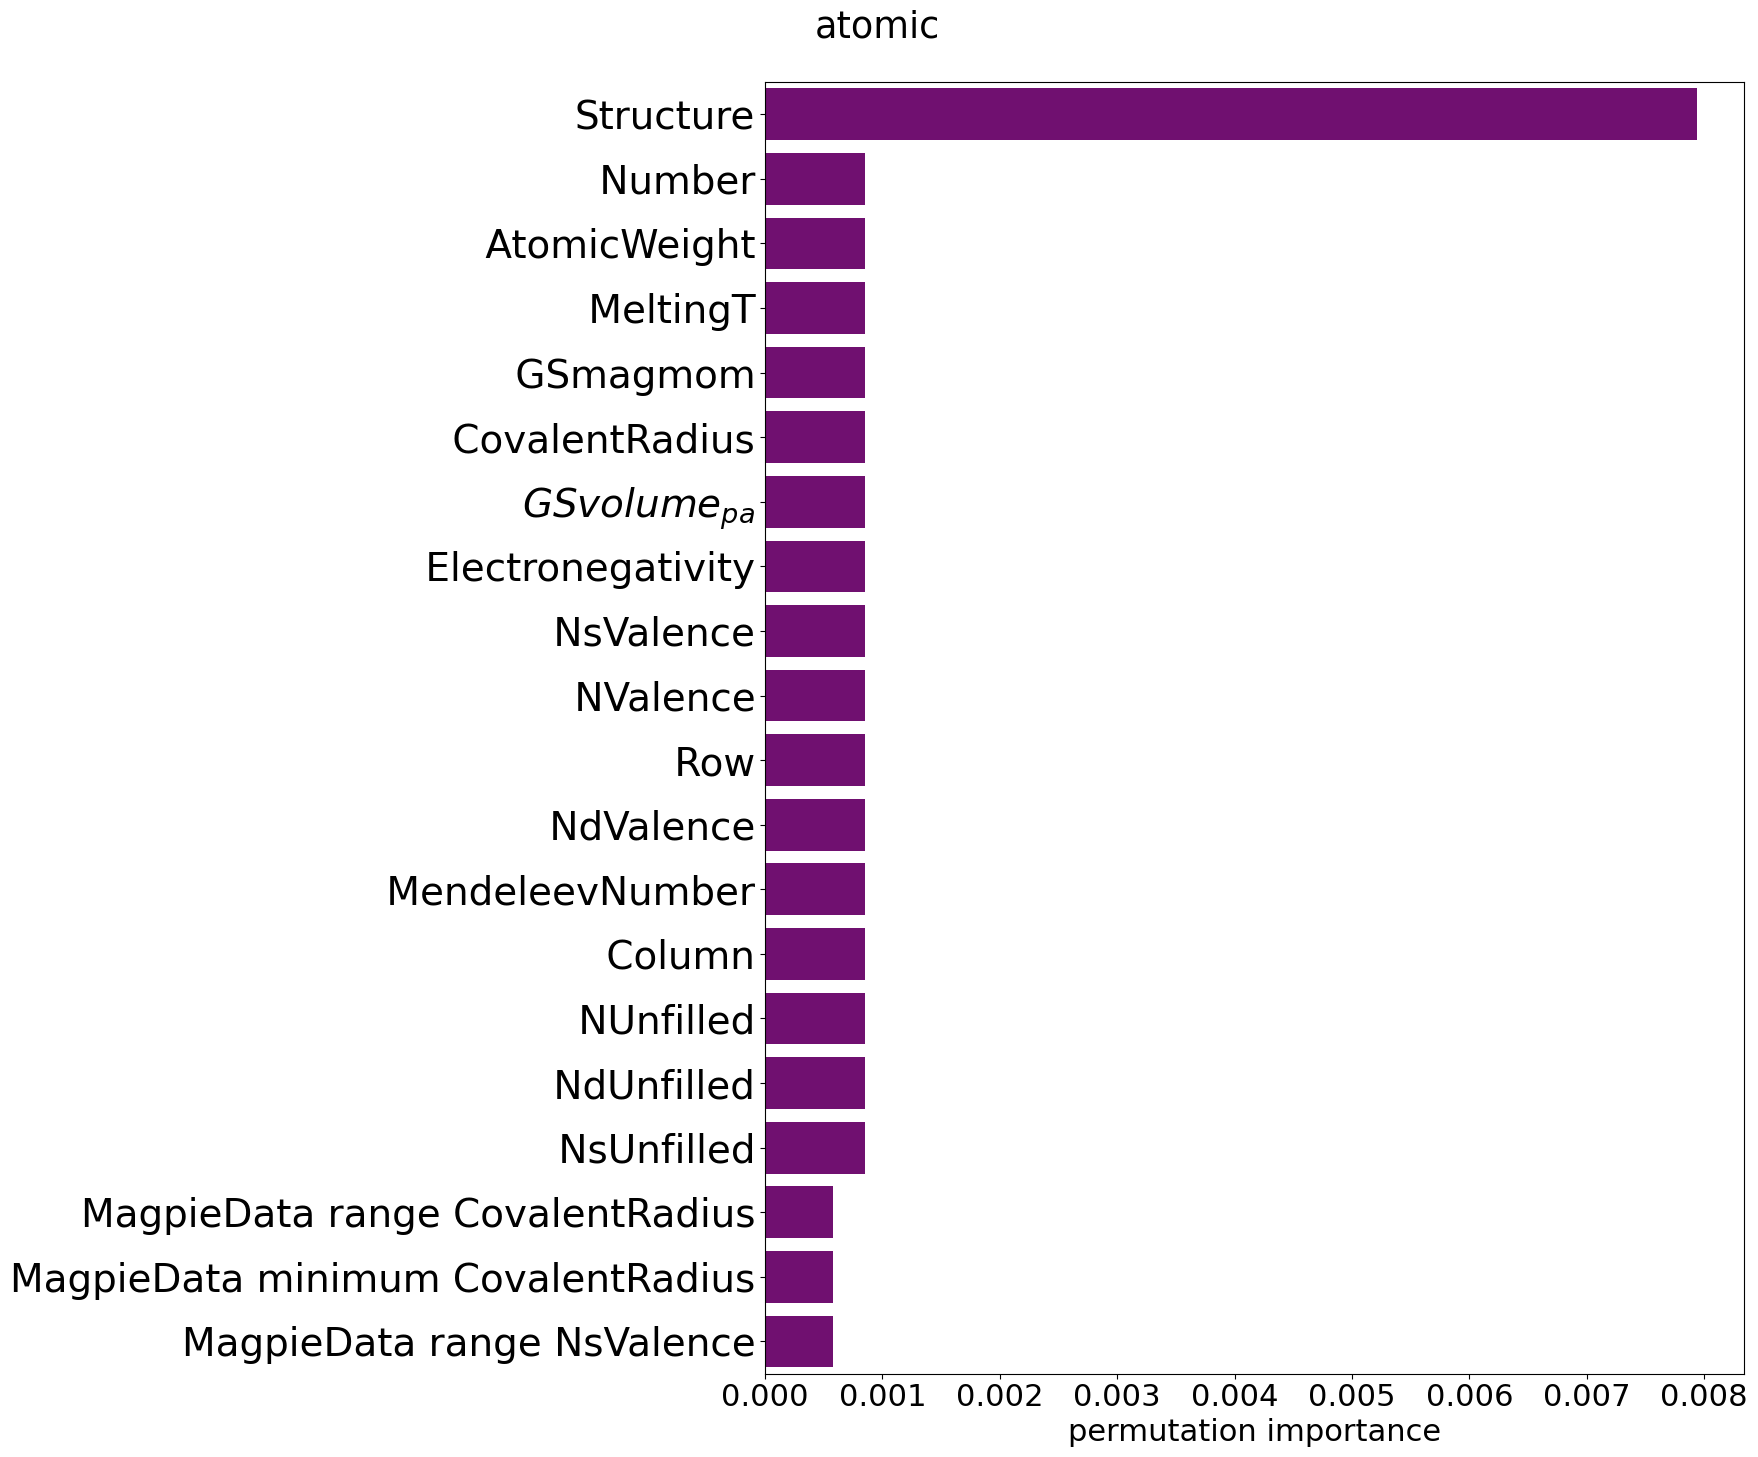

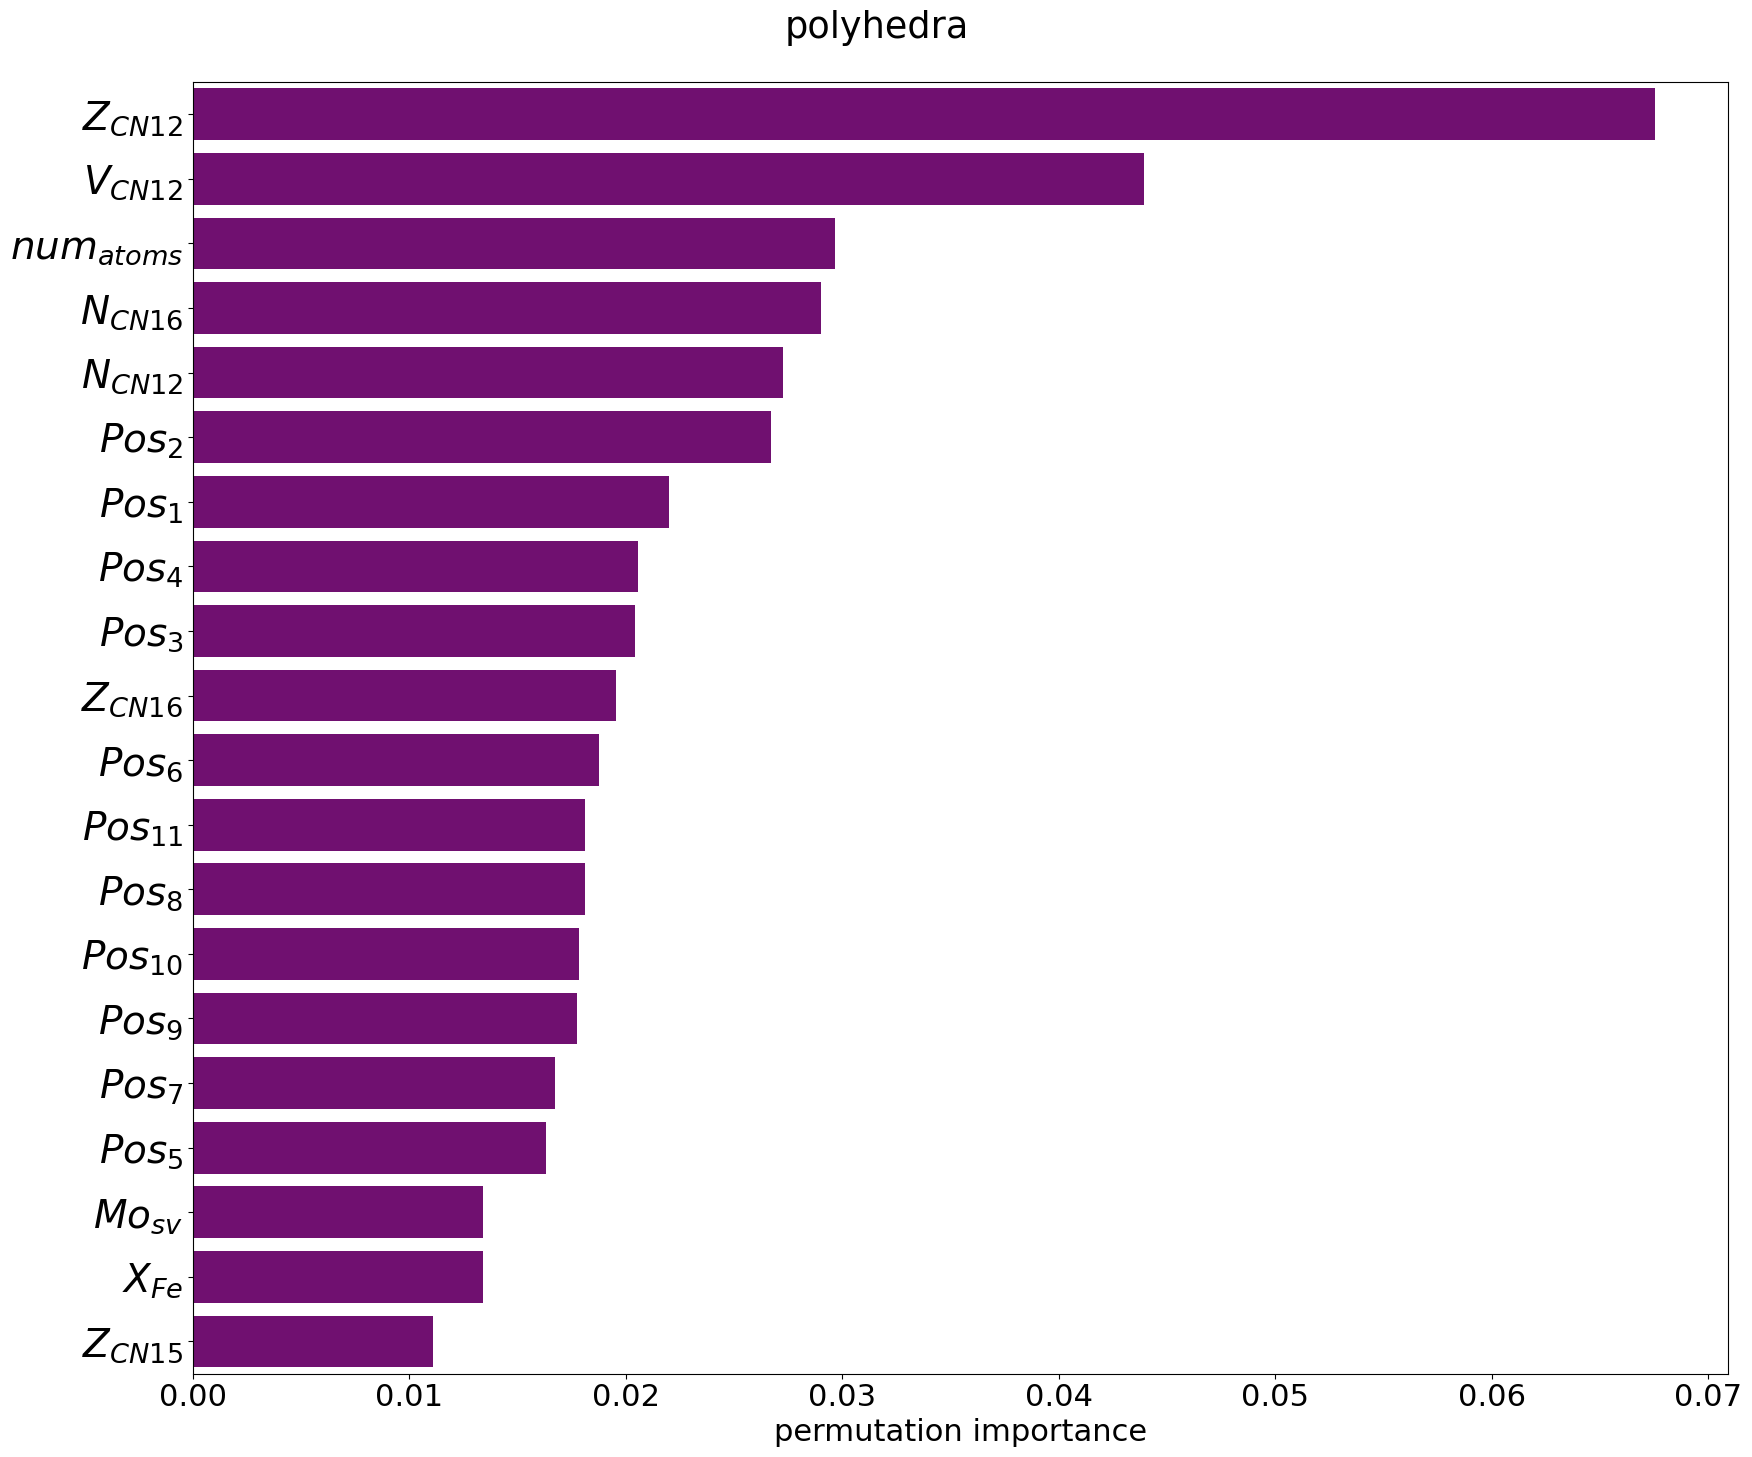

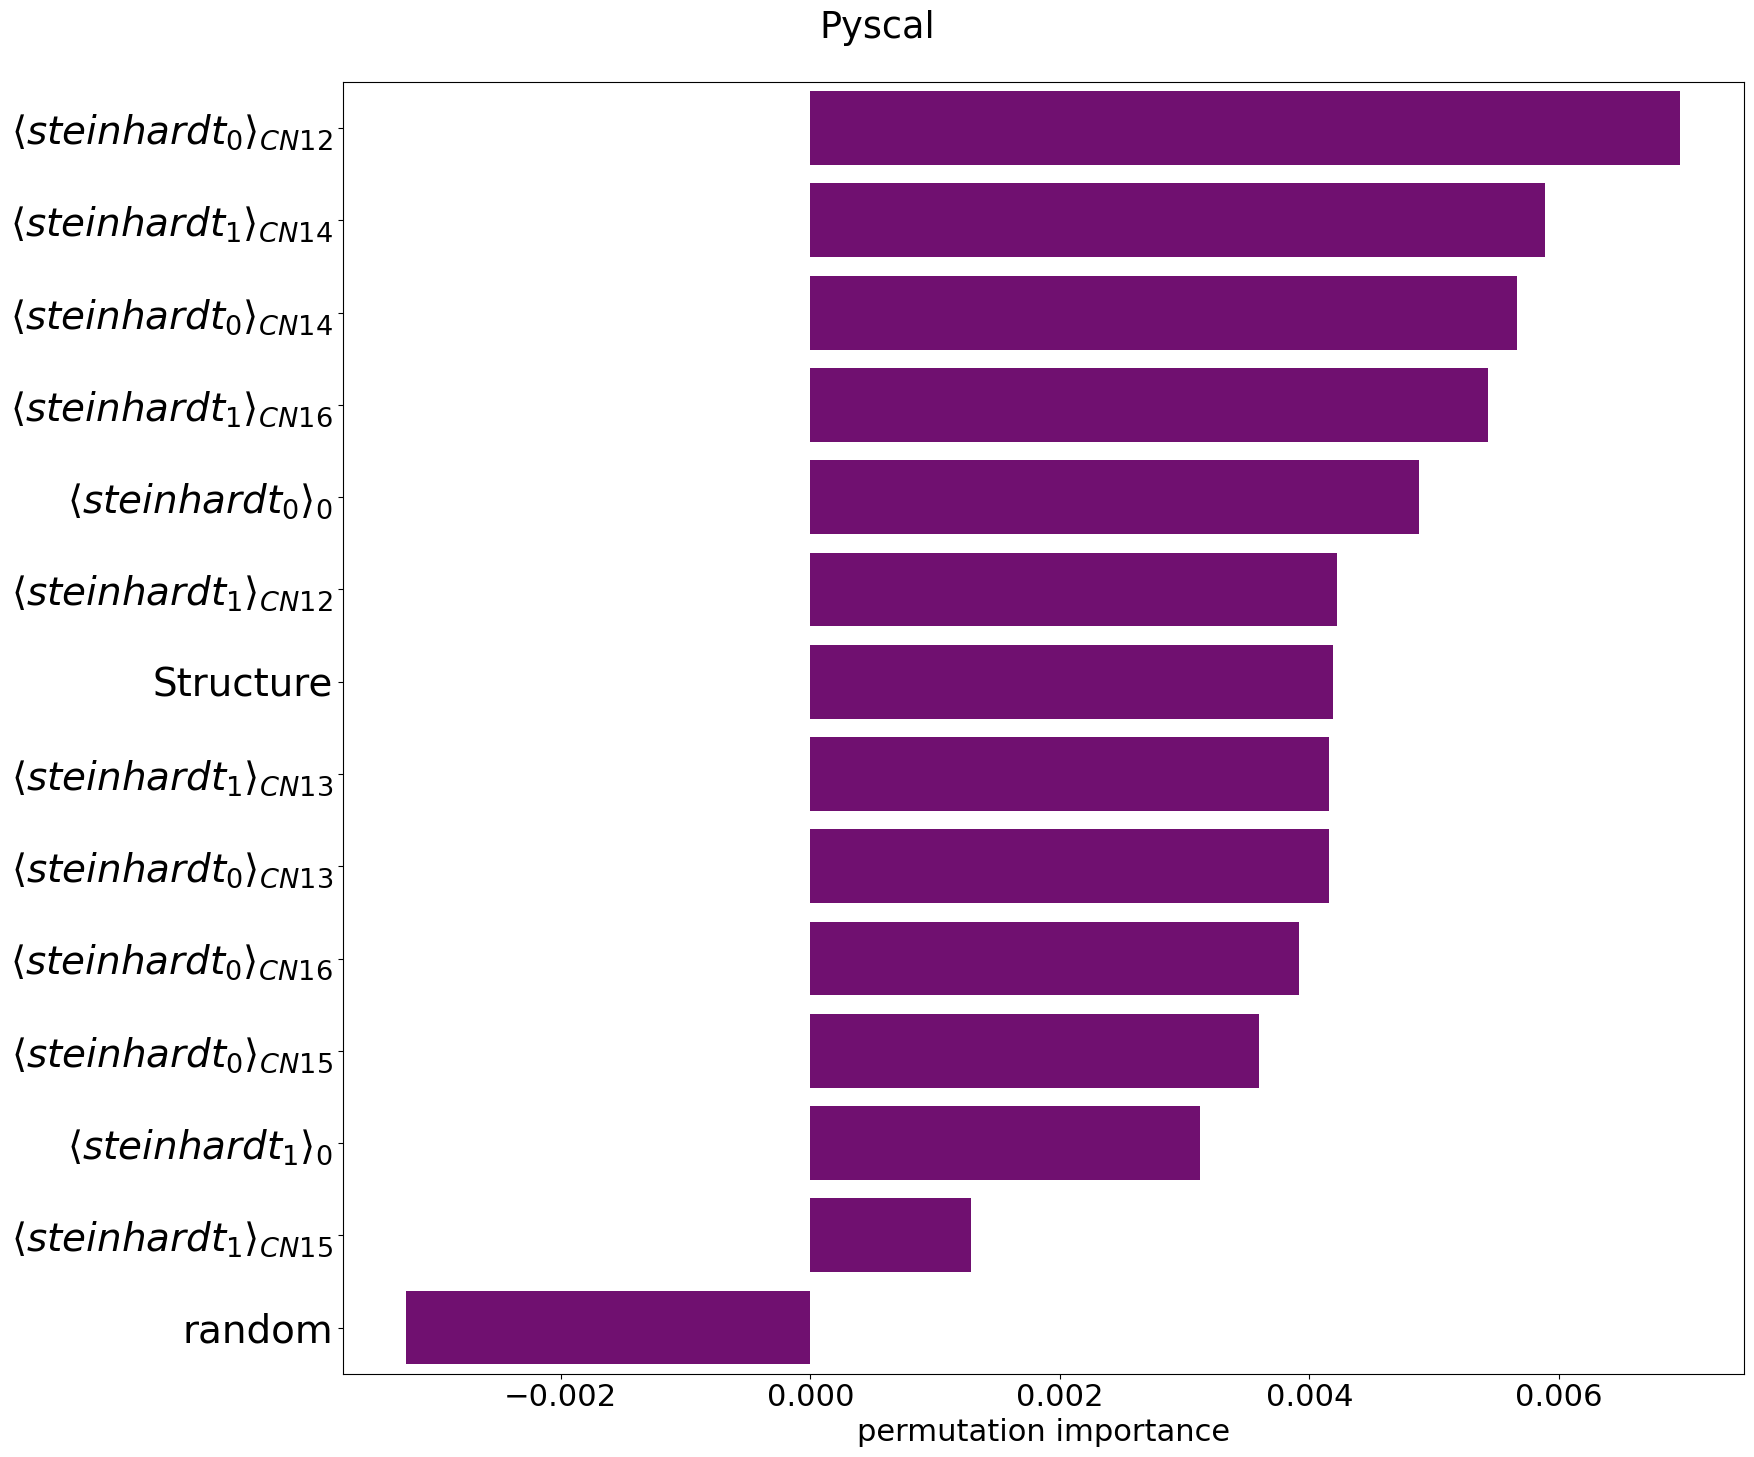

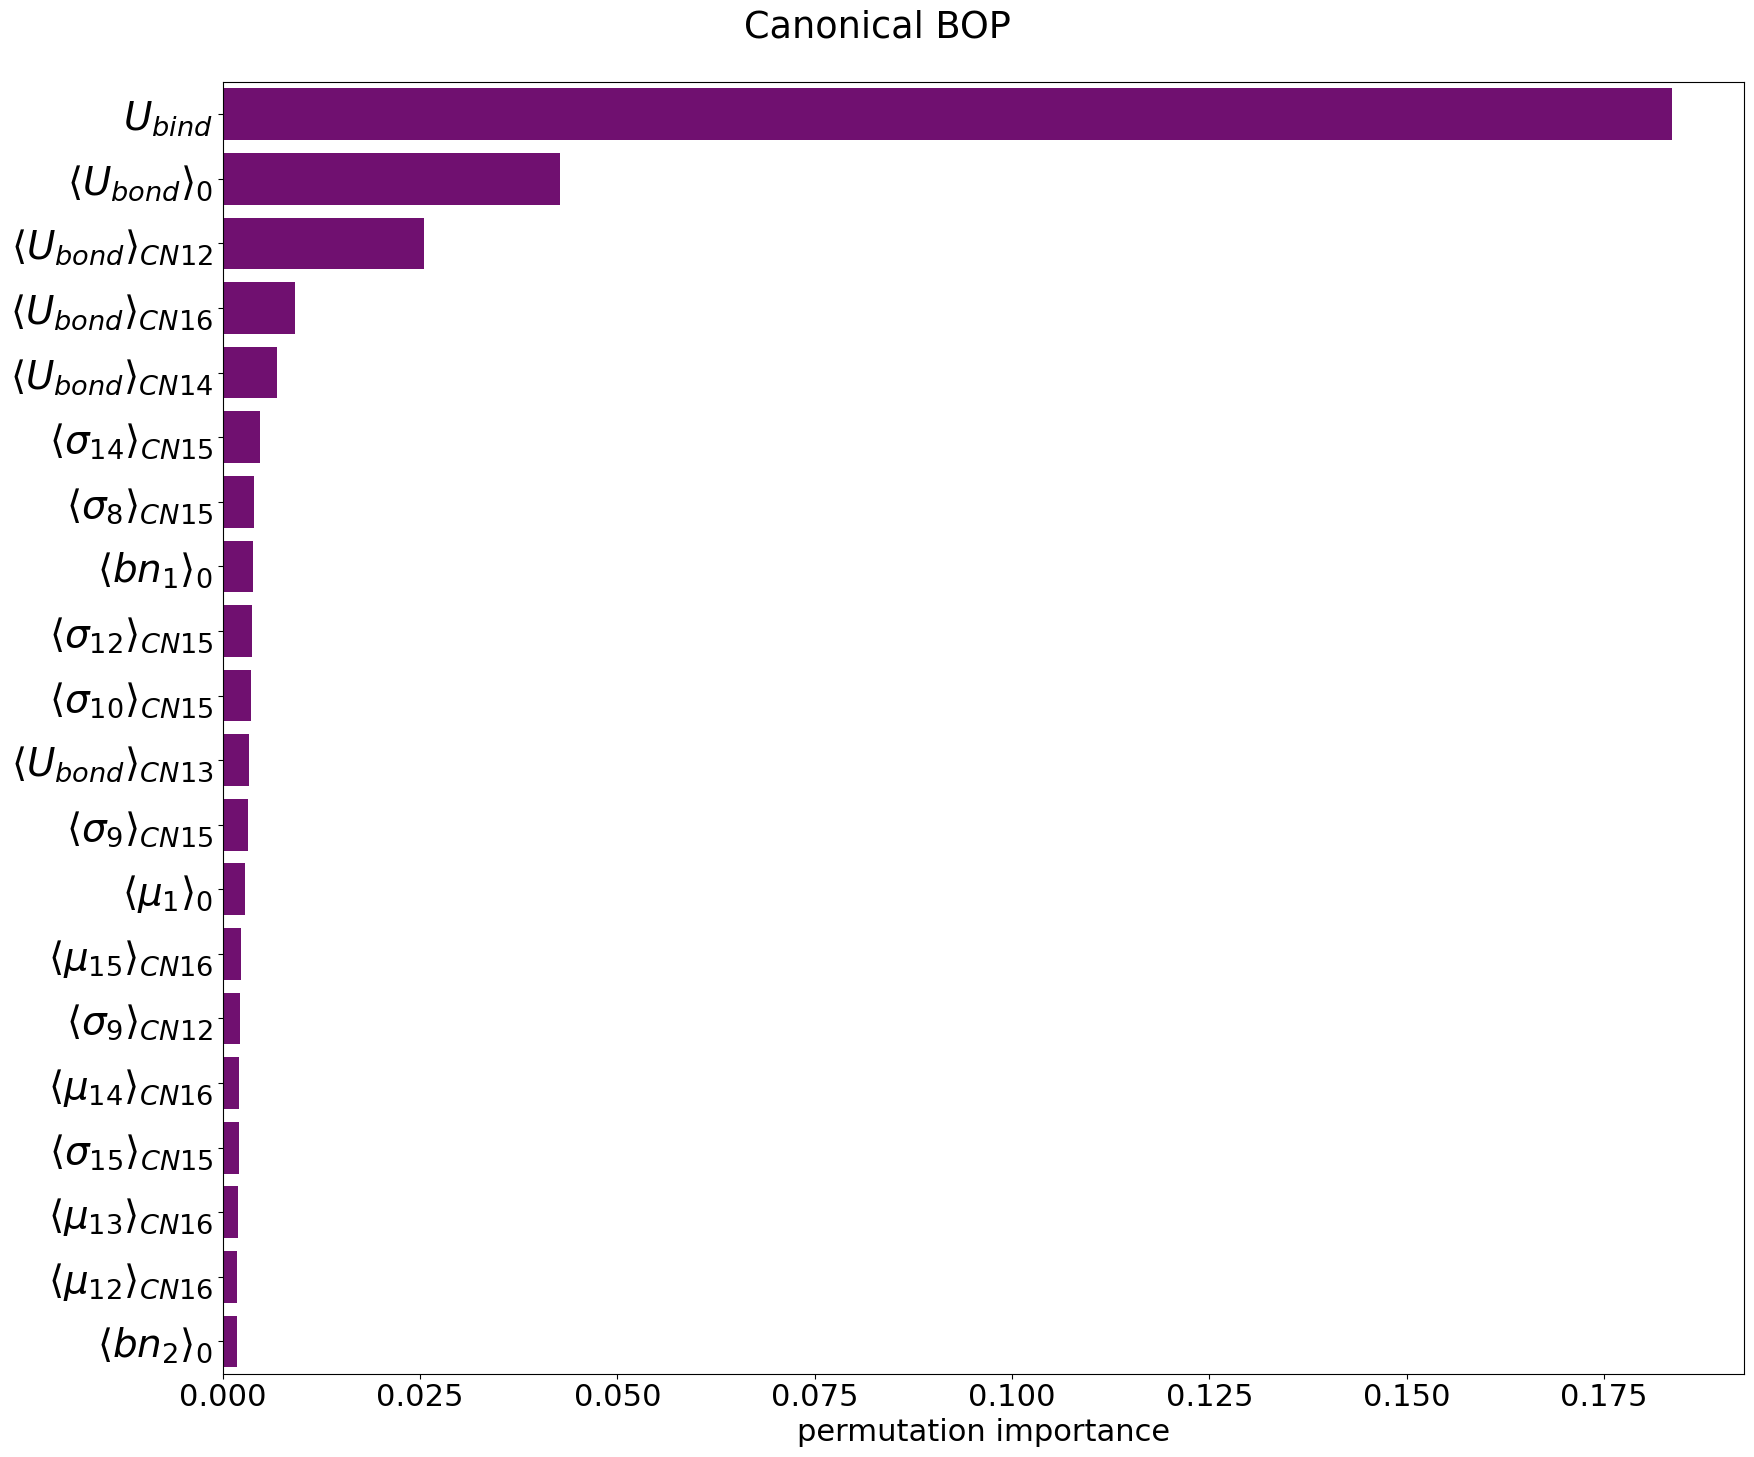

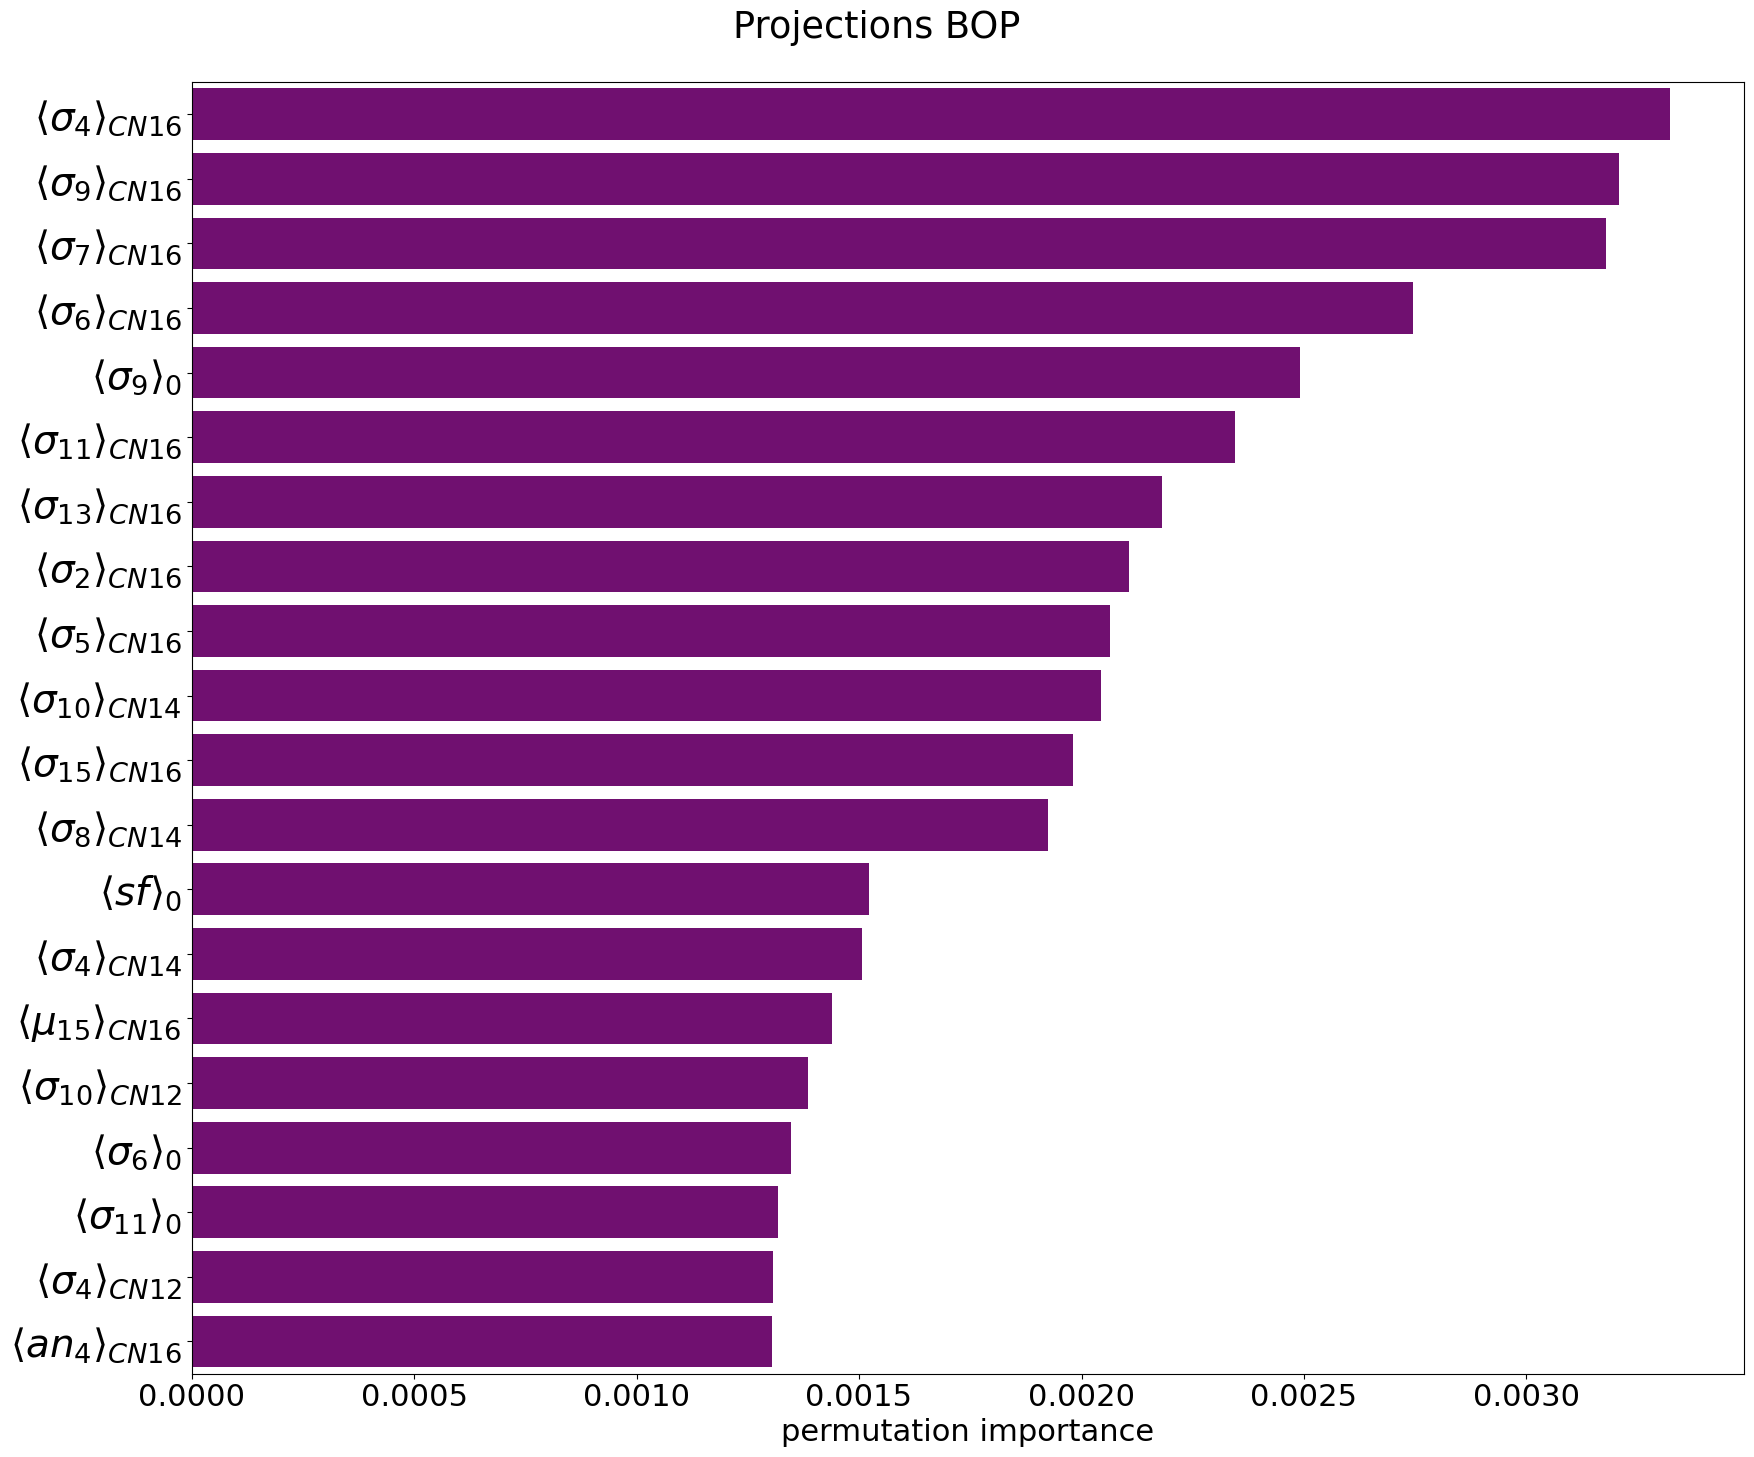

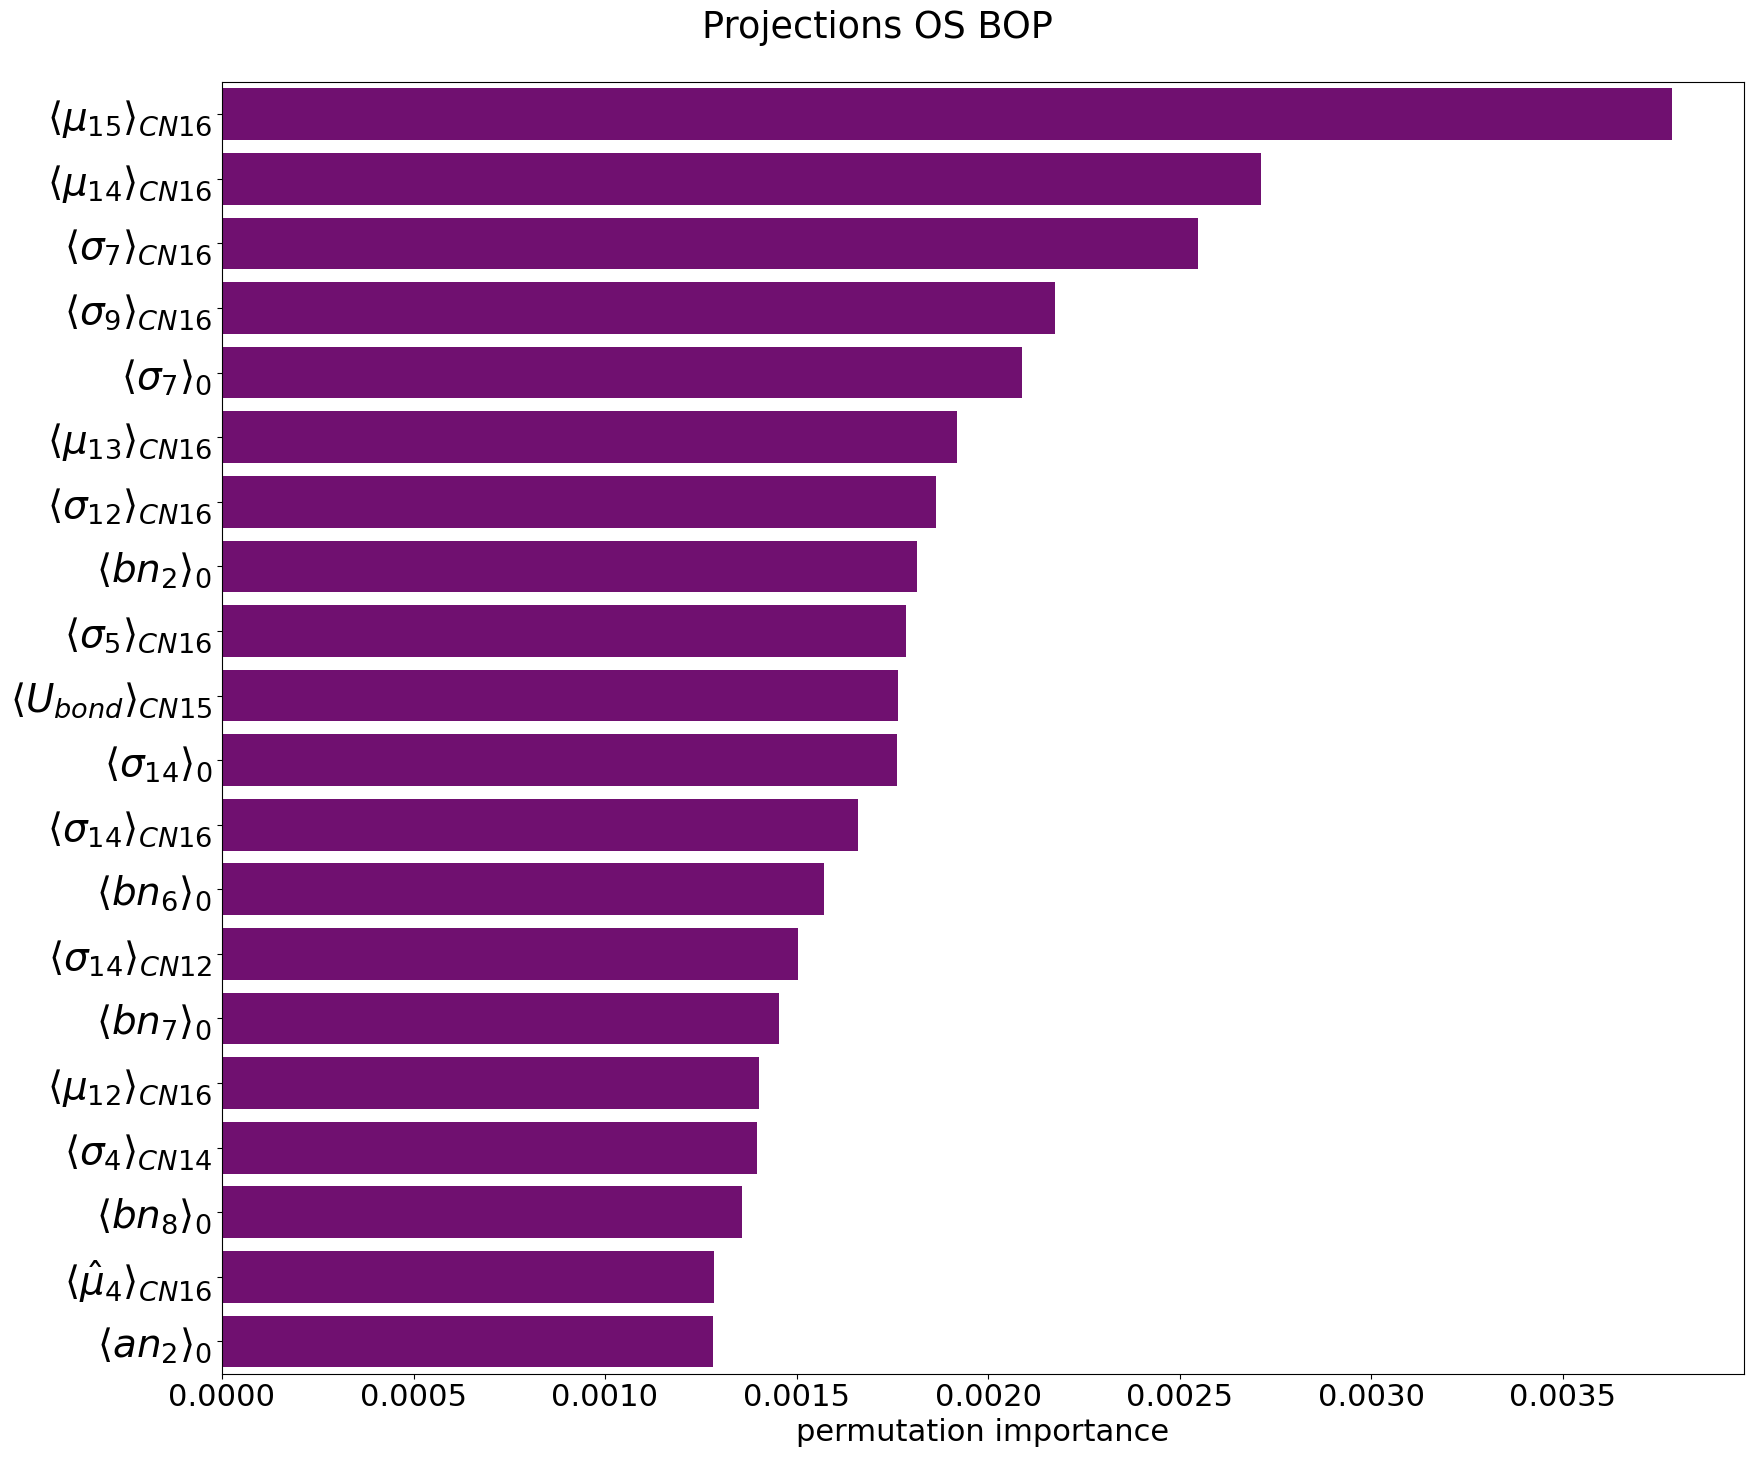

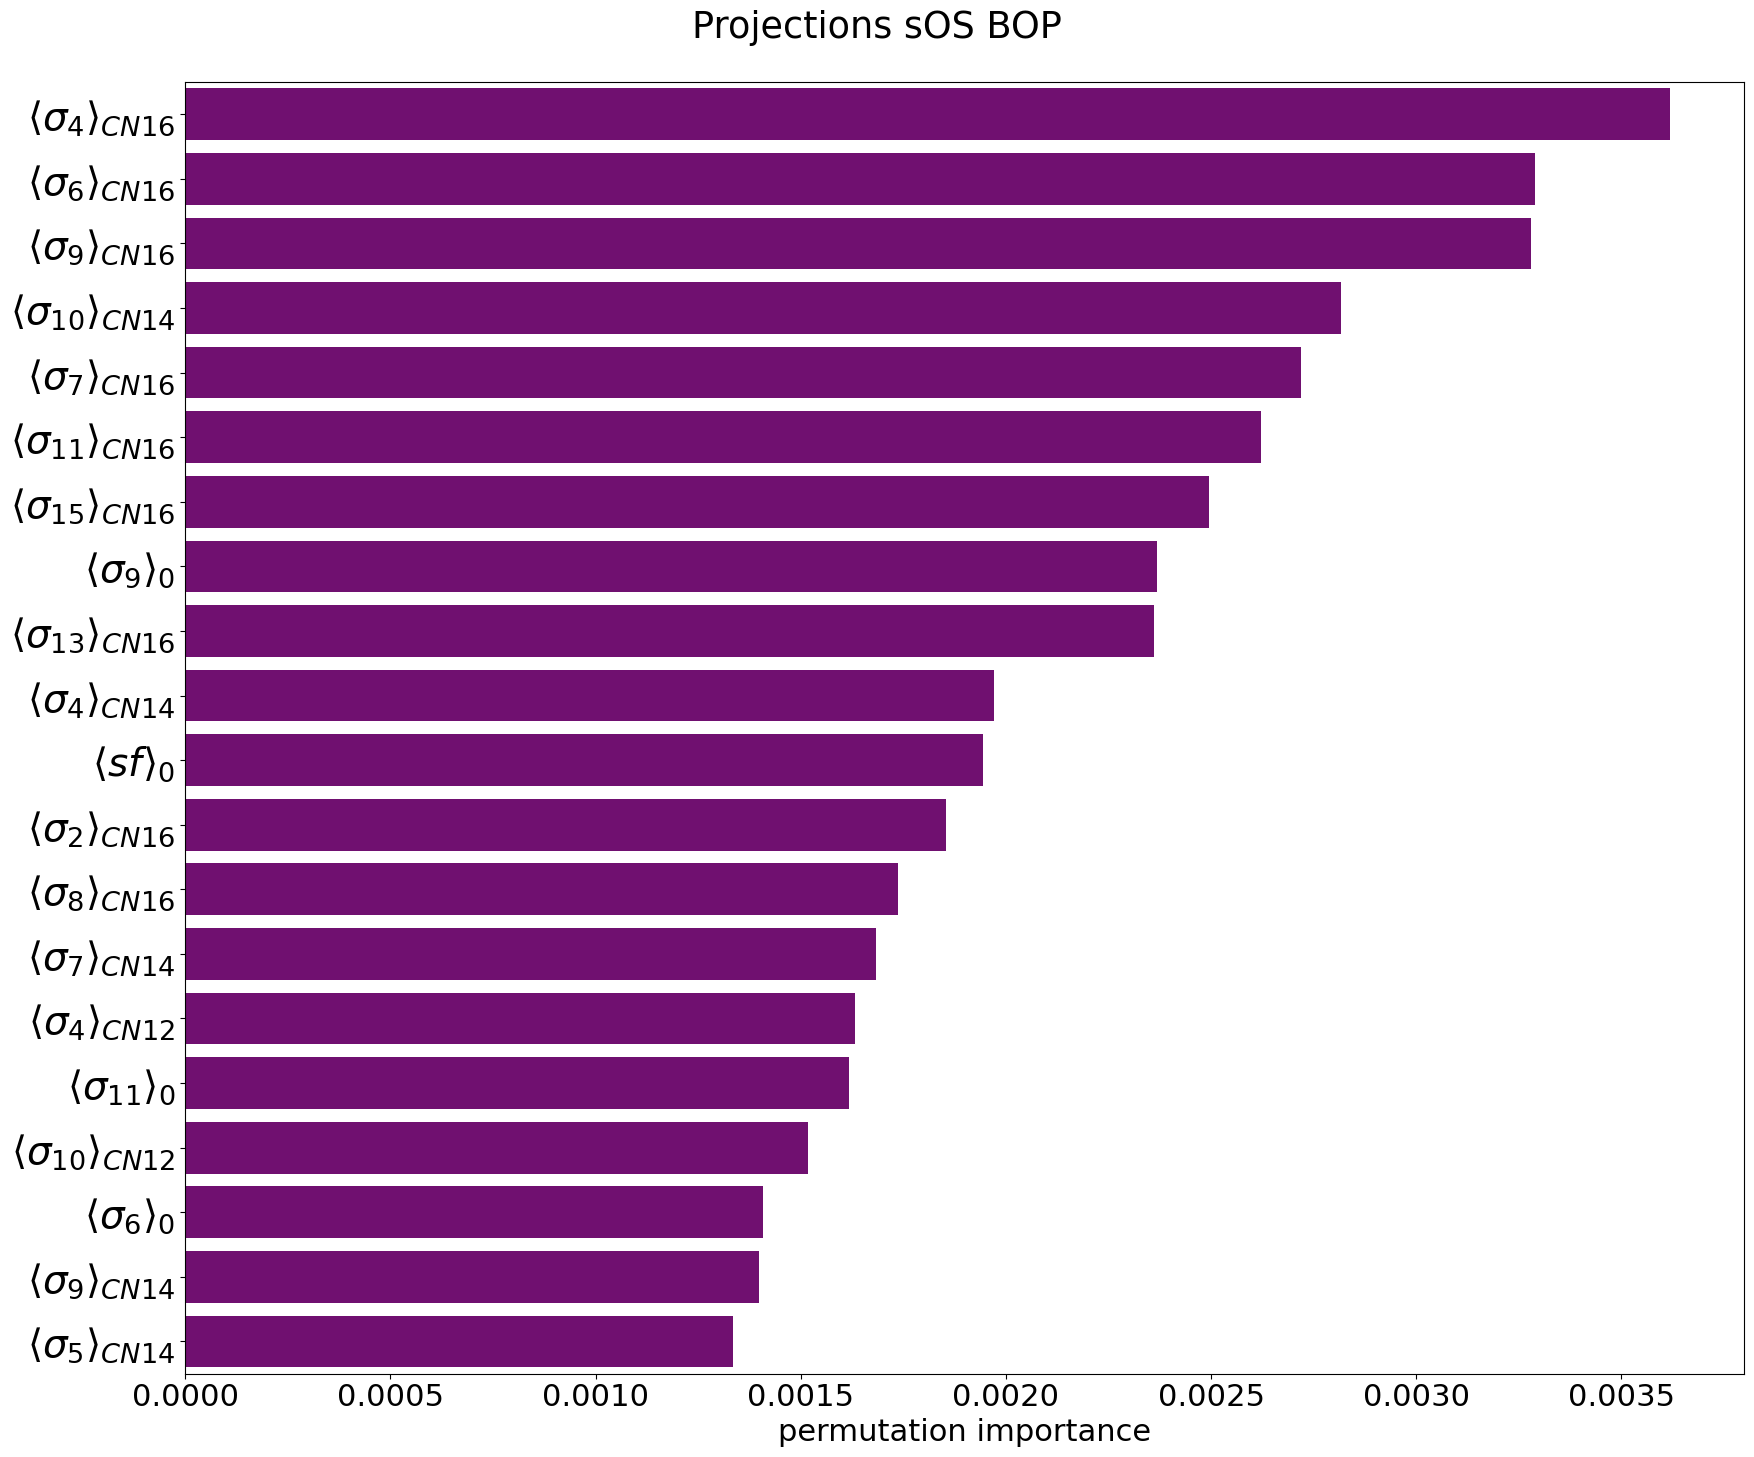

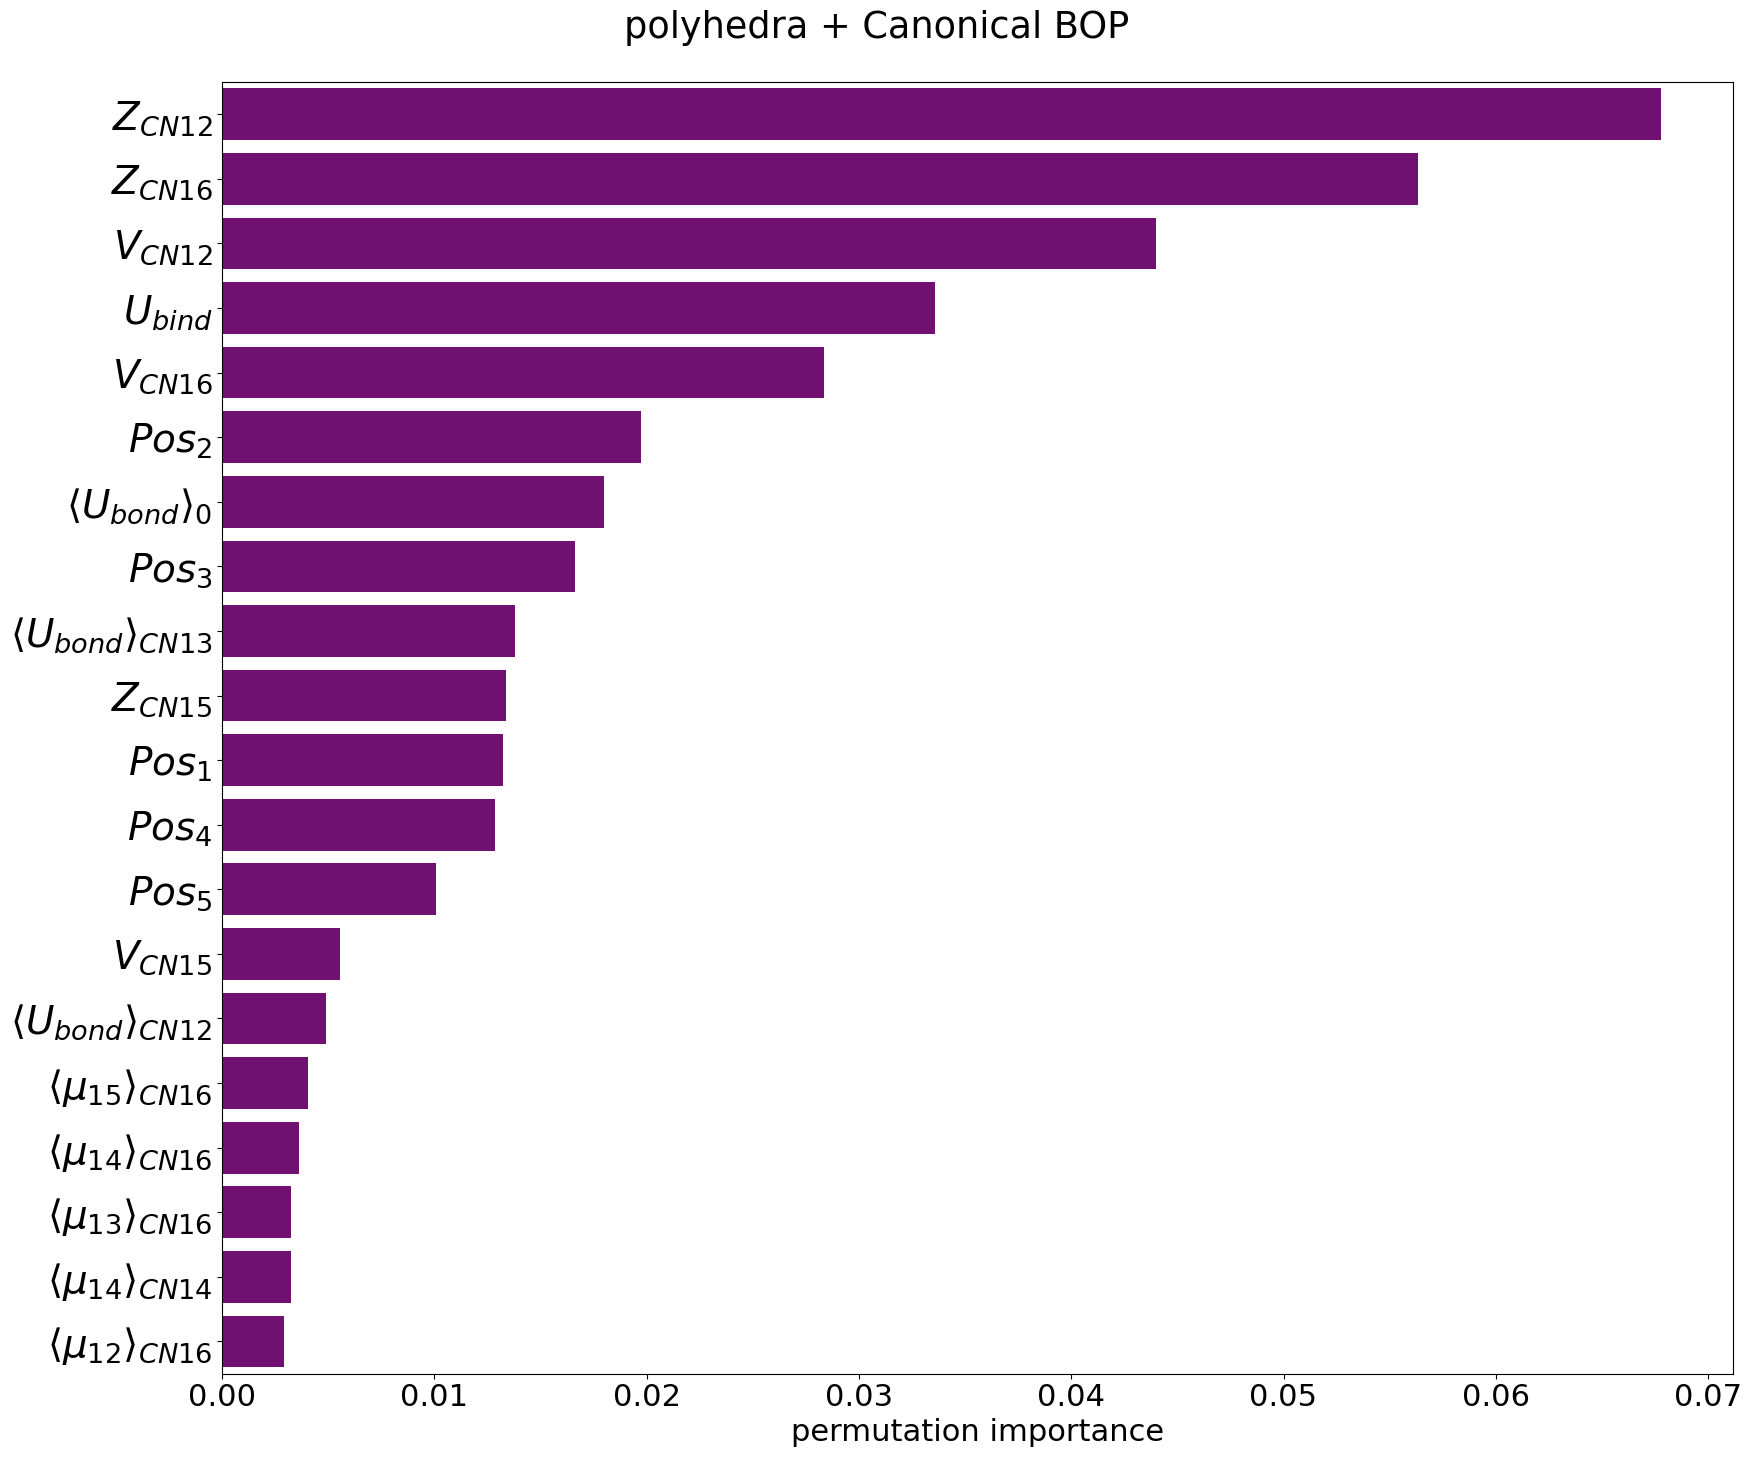

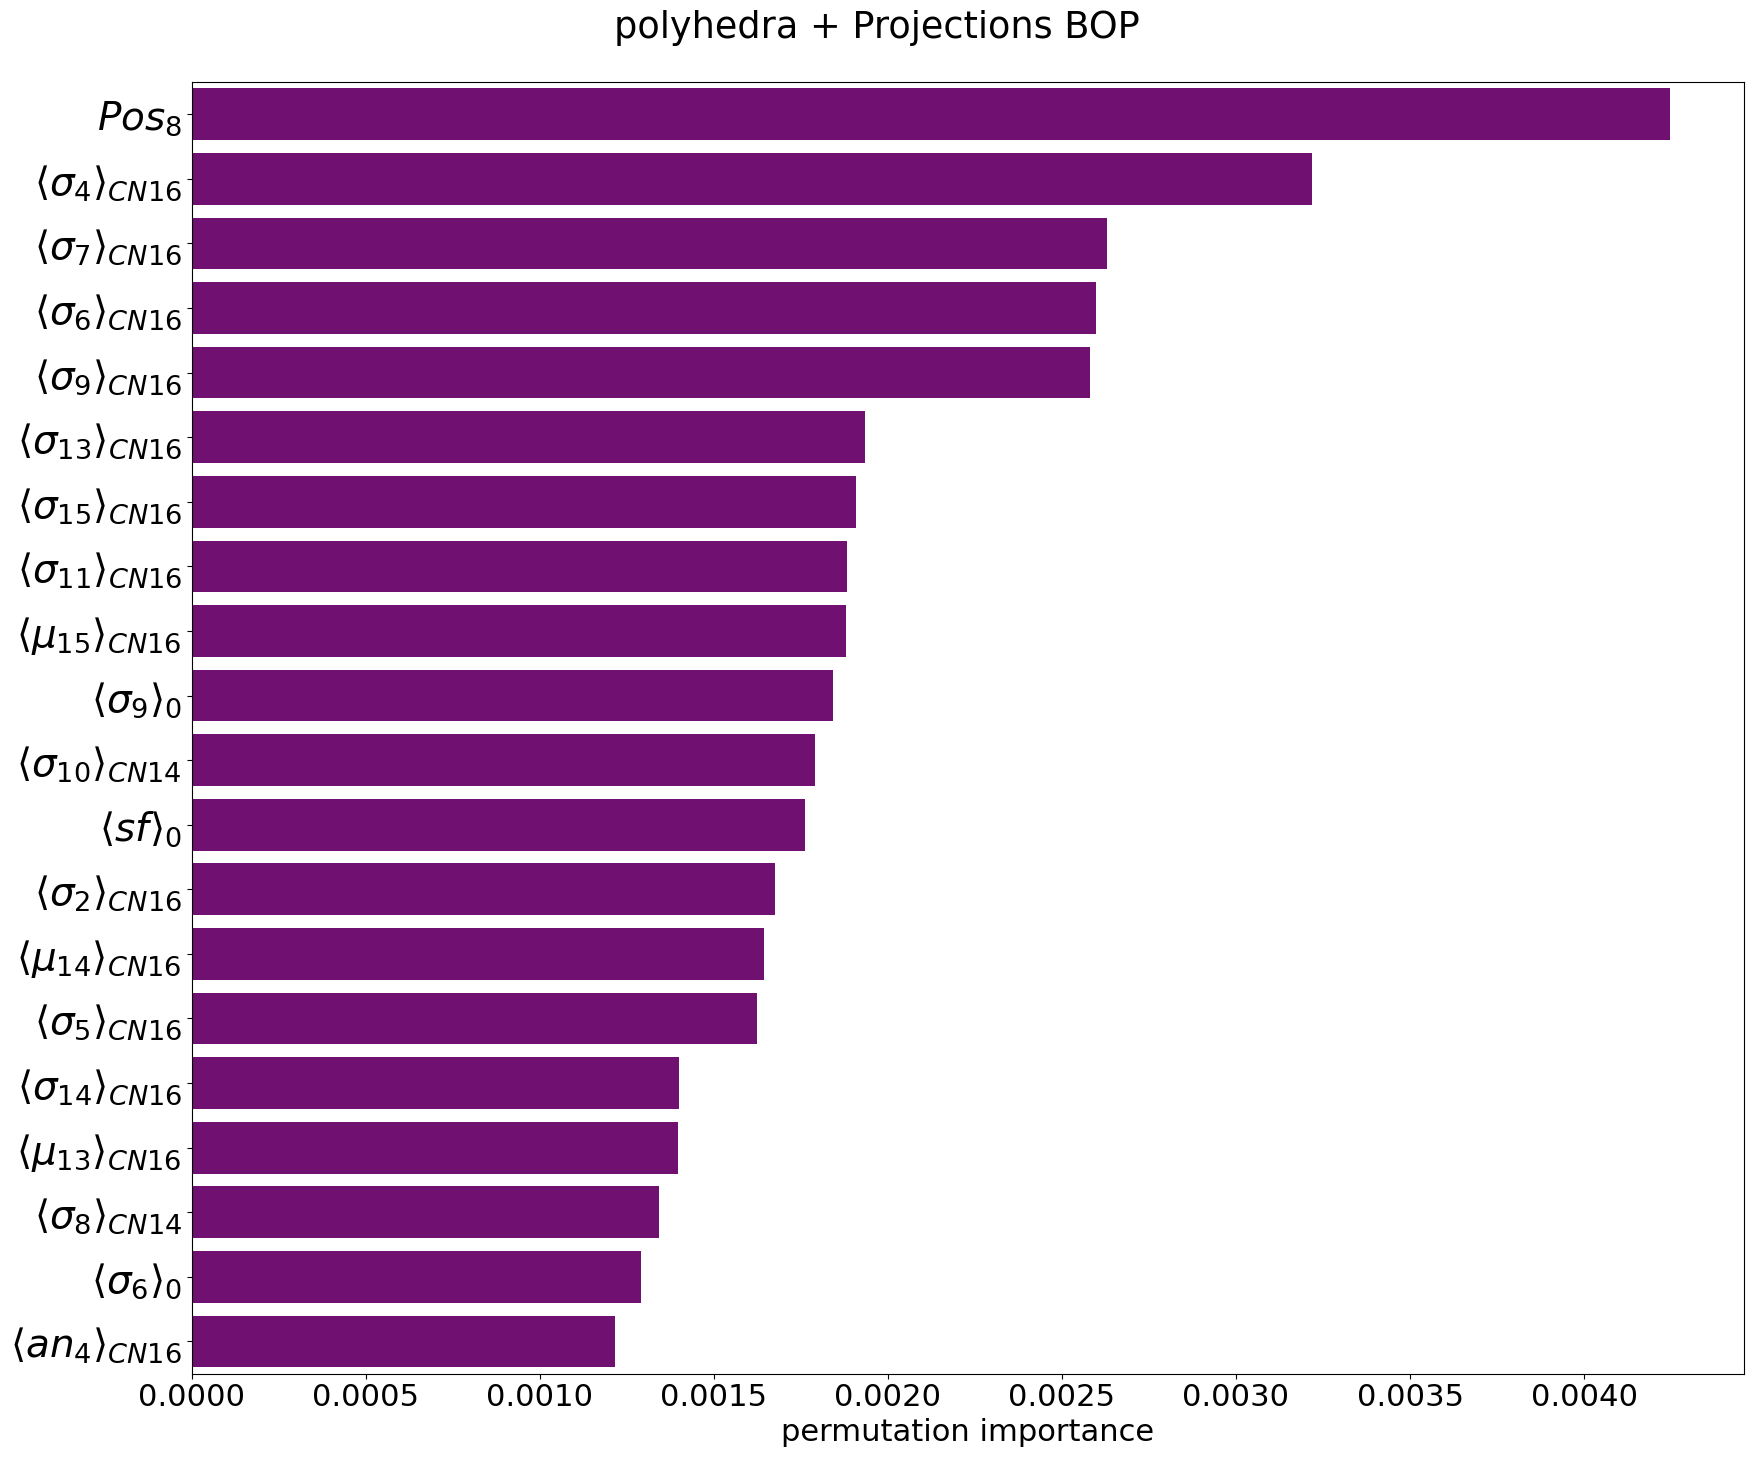

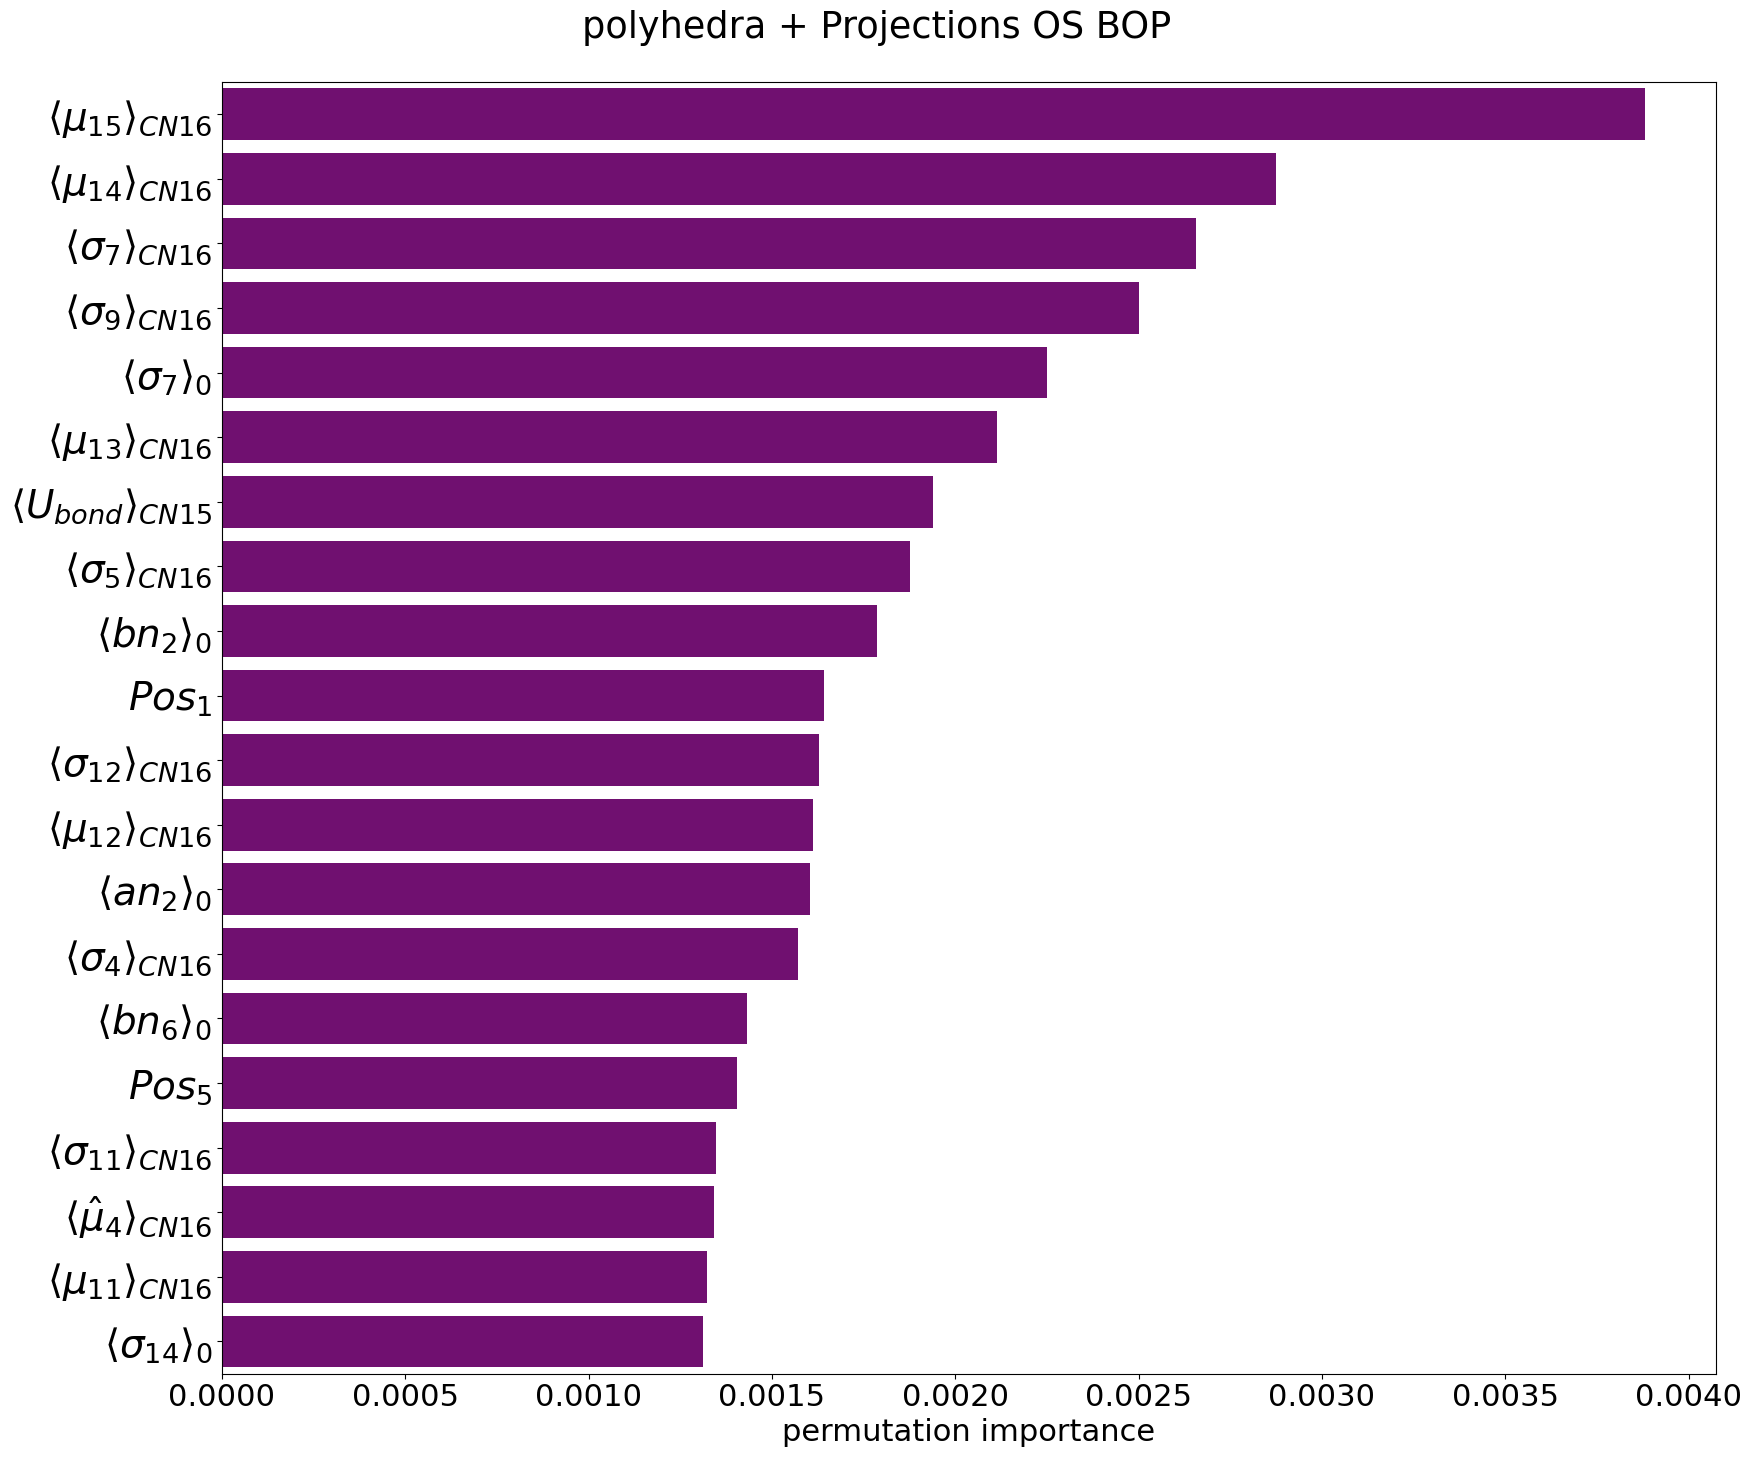

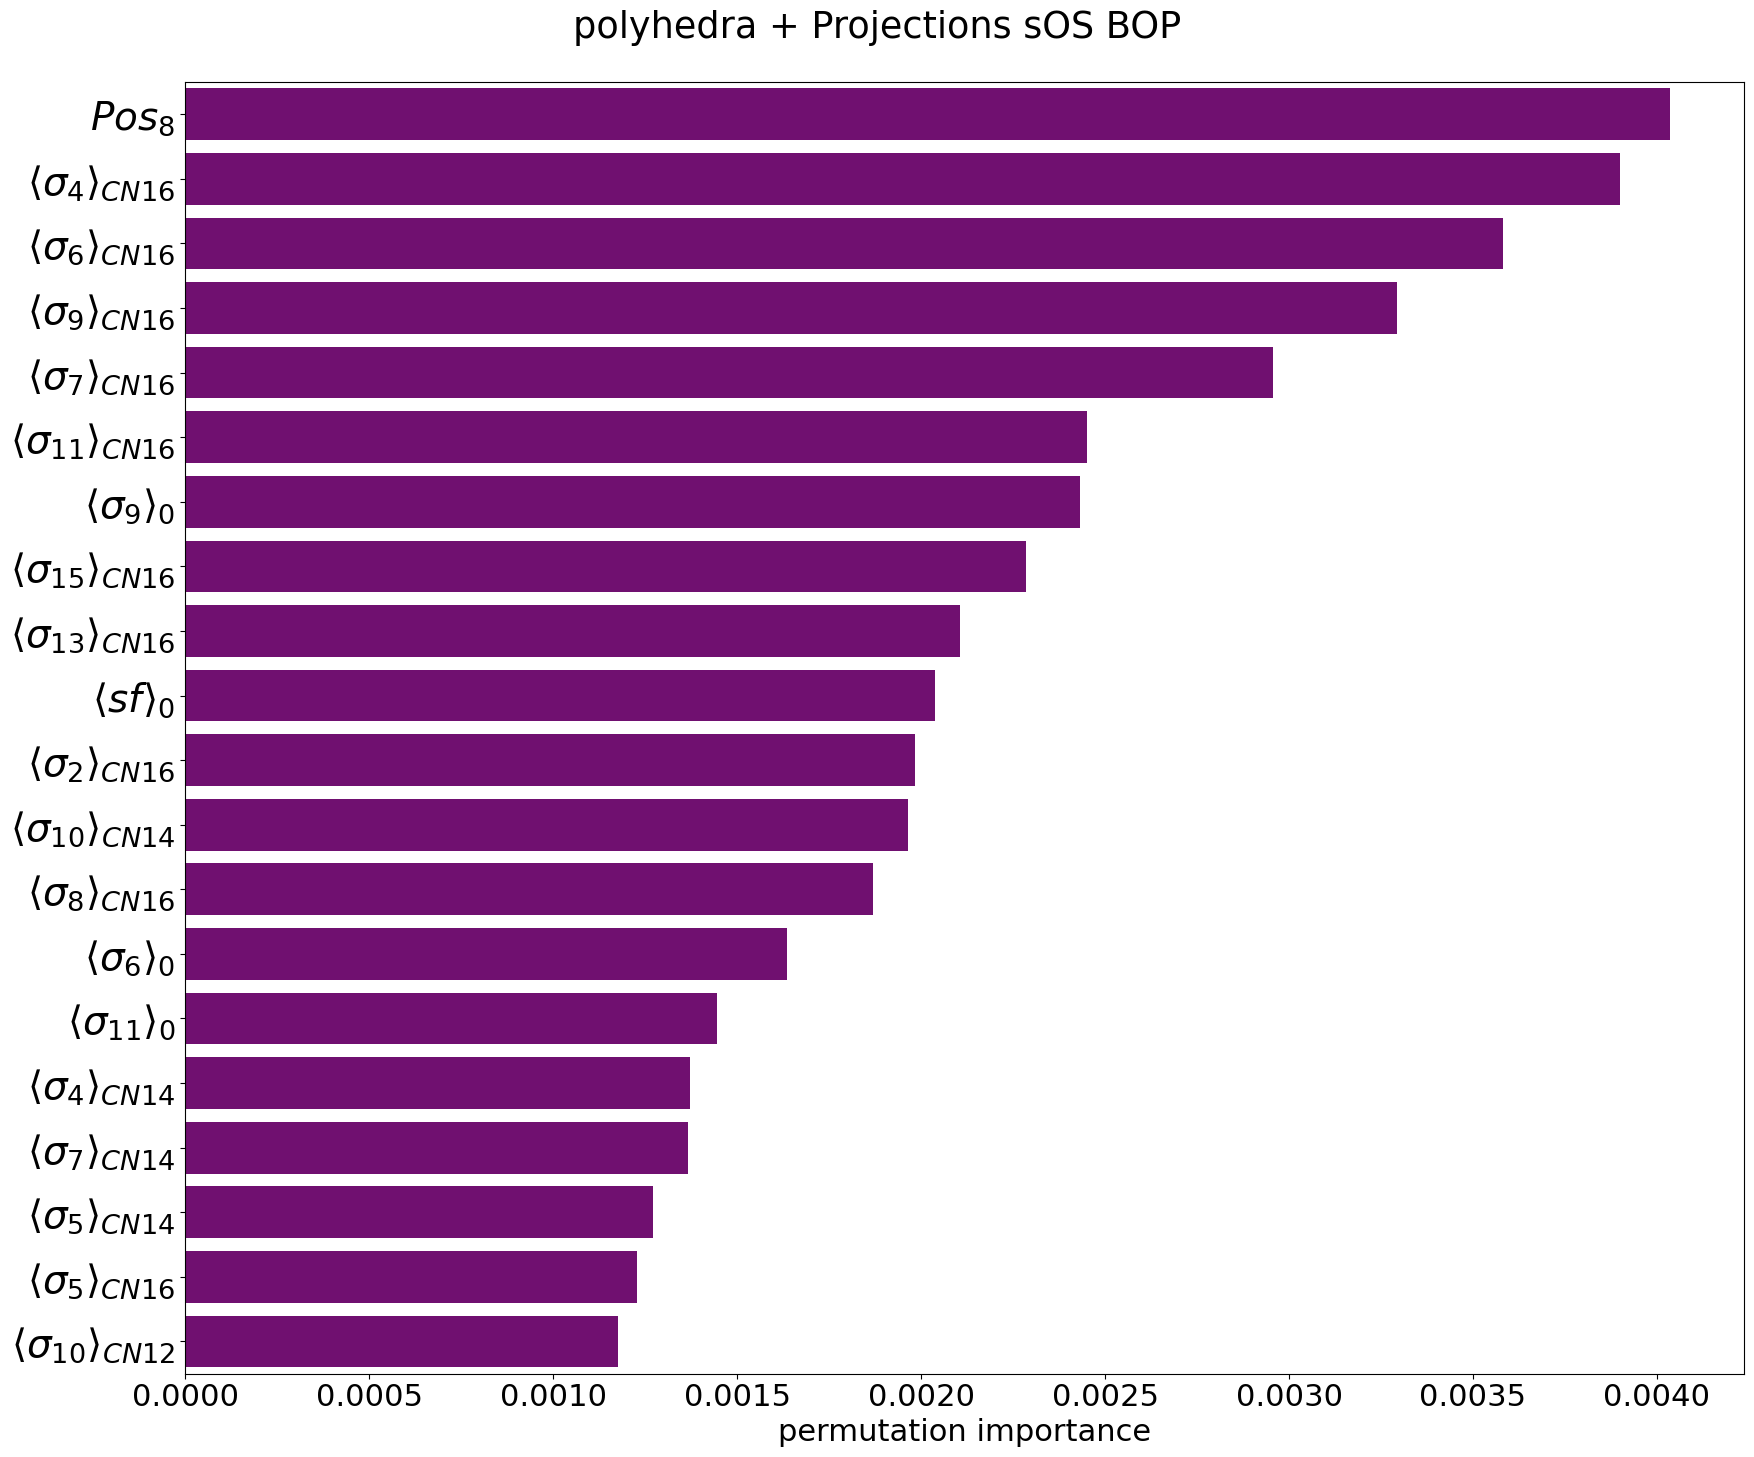

In [69]:
#for (model, name), timp in importances.items():
for (model, name), timp in importances.items(): #['Projections OS BOP', 'dataset + Projections OS BOP']:
    pimp = timp[timp.index != 'Mag']
    fig, ax = plt.subplots(figsize=(18, 15))
    x = pimp['importances_mean'][:20]
    sns.barplot(y=pimp.index[:20], x=x , ax=ax, color='Purple')
    ylabels = [get_str_formatted(fname) for fname in x.index]
    ax.set_xlabel('permutation importance')
    ax.set_yticklabels(ylabels, fontsize=28)
    fig.suptitle(name.replace('dataset', 'polyhedra'))
    fig.tight_layout()
    nameforfile  = name.replace(' ','')
    fig.savefig(f'{DS.dataset}/graphs/{DS.dataset}_permutation_importance_{nameforfile}.eps')

# Feature Concatenation 

In [70]:
FeatureConcatenate = SourceFileLoader('FeatureConcatenate', 'Tools/DatasetTools/FeatureConcatenate.py').load_module().NewFeatureConcatenate
#from BopFoxFeaturizer.FeatureConcatenate import FeatureConcatenate

In [71]:
feature_concat_resul_loc = os.path.join(DS.dataset, 'results', 'concatenation_results.pkl')
if os.path.exists(feature_concat_resul_loc):
    with open (feature_concat_resul_loc, 'rb') as pkl:
        FCresults = pickle.load(pkl)

In [81]:
for group in DS.Features.keys(): #['Canonical BOP']:
    model = copy.deepcopy(Models[ModelName])
    combi = (ModelName, group)
    if combi in FCresults.keys():
        continue
    FC =  FeatureConcatenate(DS, model, FittedModels[combi].best_params_,)
    FCresults[combi] = FC.get_best_features_list(group)
    with open(feature_concat_resul_loc, 'wb') as pkl:
        pickle.dump(FCresults, pkl)

fitting random: 100%|██████████| 393/393 [00:06<00:00, 61.42it/s]                


            test     train
bn_4_0  0.101682  0.120197


fitting sigma_9_CN16: 100%|██████████| 392/392 [00:06<00:00, 60.69it/s]          


               test     train
sigma_9_0  0.085033  0.084919


fitting random: 100%|██████████| 422/422 [00:05<00:00, 79.35it/s]                


...

fitting random: 100%|██████████| 422/422 [00:06<00:00, 63.01it/s]                


            test     train
bn_4_0  0.101682  0.120197


fitting sigma_9_CN16: 100%|██████████| 421/421 [00:06<00:00, 62.39it/s]          


               test     train
sigma_9_0  0.085033  0.084919


KeyError: ('Kernel Ridge', 'Canonical BOP no CNAV')

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


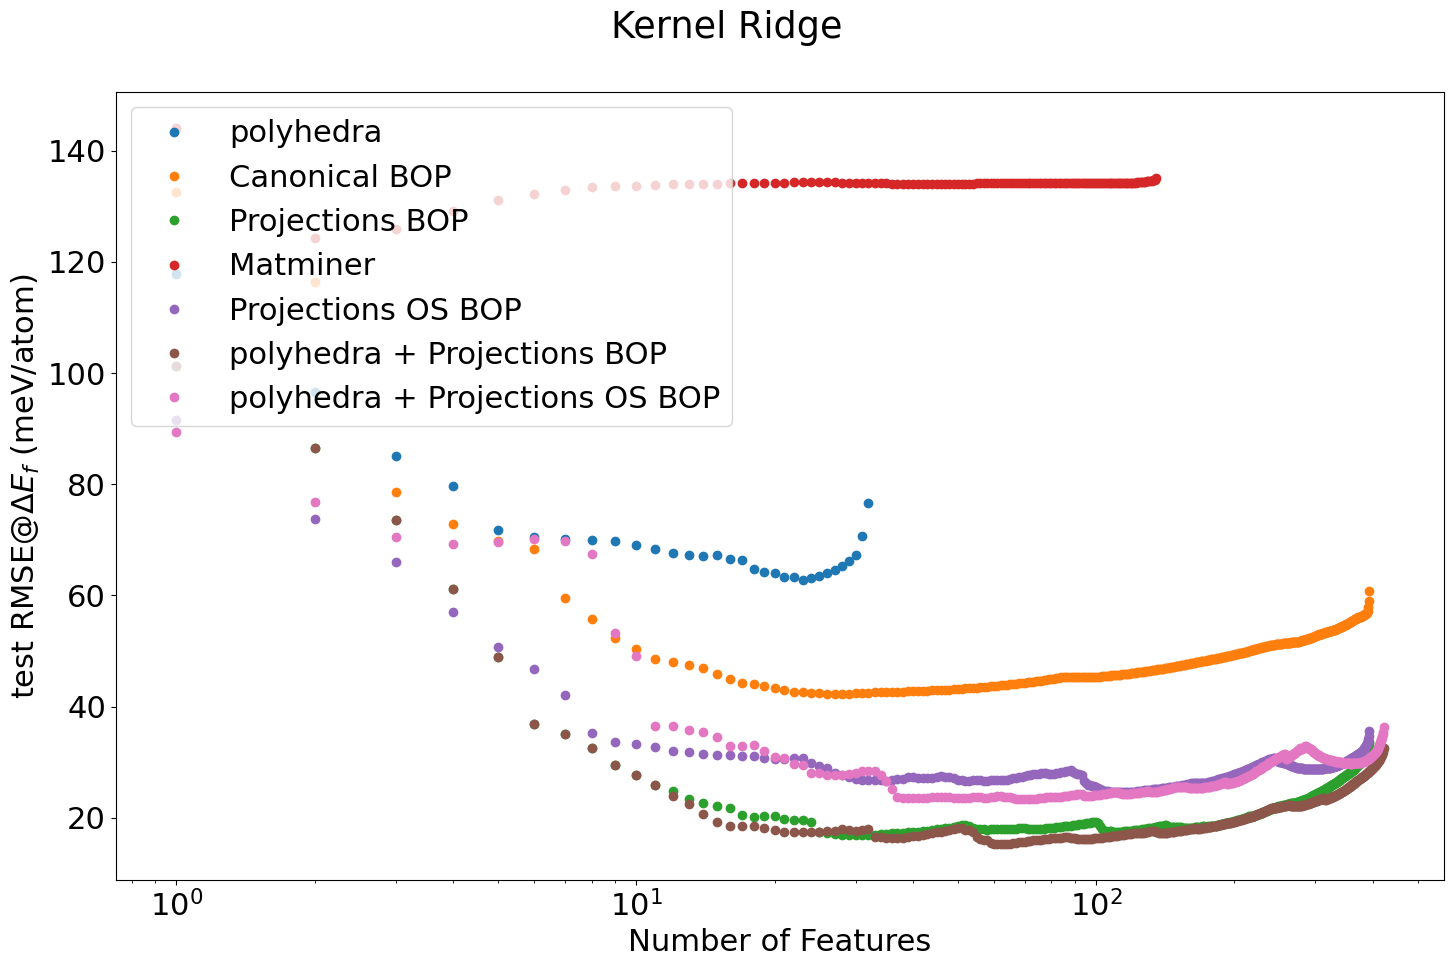

In [73]:
from matplotlib.ticker import FormatStrFormatter
fig, axes = plt.subplots()
for combi, result in FCresults.items():
    nfeats = result.shape[0]
    x=np.linspace(1,nfeats, nfeats)
    legend = combi[1].replace('dataset', 'polyhedra')
    legend = legend.replace('atomic', 'Matminer')
    axes.plot(x, result['test']*1000,'o', label=legend)
axes.set_xscale('log')
axes.set_ylabel(r'test RMSE@$\Delta E_f$ (meV/atom)')
axes.set_xlabel('Number of Features')
axes.tick_params(axis='y', which='minor')
axes.yaxis.set_minor_formatter(FormatStrFormatter("%.0f"))
plt.legend()

labels = [get_str_formatted(l) for l in FCresults[(ModelName, 'Projections BOP')].index[:10]]
text = '\n'.join(labels)
fig.suptitle('Kernel Ridge')
fig.tight_layout()
fig.savefig(f'{DS.dataset}/graphs/{DS.dataset}_LearningCurves.eps')

# Final learn after feature selection 

In [74]:
FCresults.keys()

dict_keys([('Kernel Ridge', 'dataset'), ('Kernel Ridge', 'Canonical BOP'), ('Kernel Ridge', 'Projections BOP'), ('Kernel Ridge', 'atomic'), ('Kernel Ridge', 'Projections OS BOP'), ('Kernel Ridge', 'dataset + Projections BOP'), ('Kernel Ridge', 'dataset + Projections OS BOP')])

In [75]:
OptimalFittedScores = {}

In [76]:
for combi in FCresults.keys():
    amodel  = copy.deepcopy(Models[ModelName])
    params = FittedModels[combi].best_params_
    amodel.set_params(**params) #= GridSearchCV(amodel, MO.modeloptions[ModelName], scoring = 'neg_root_mean_squared_error',return_train_score=True)
    atmin = FCresults[combi]['test'].argmin()
    selected = FCresults[combi].index[:atmin]
    X = DS.Features[combi[1]][selected]
    amodel.fit(X.loc[DS.samplesplit['train']], DS.target[DS.samplesplit['train']])
    OptimalFittedScores[combi] = score_fitted_model(amodel, X.loc[DS.samplesplit['train']], X.loc[DS.samplesplit['test']], DS.target[DS.samplesplit['train']], DS.target[DS.samplesplit['test']] )

In [77]:
OptimalFittedScores = pd.DataFrame.from_dict(OptimalFittedScores, orient='index')

In [78]:
OptimalFittedScores.unstack(level=0)

,test,train
,Kernel Ridge,Kernel Ridge
Canonical BOP,0.042308,0.028830
Projections BOP,0.016920,0.018293
Projections OS BOP,0.028595,0.012709
atomic,0.144094,0.156820
dataset,0.063397,0.035090
dataset + Projections BOP,0.015521,0.014164
dataset + Projections OS BOP,0.023371,0.012820


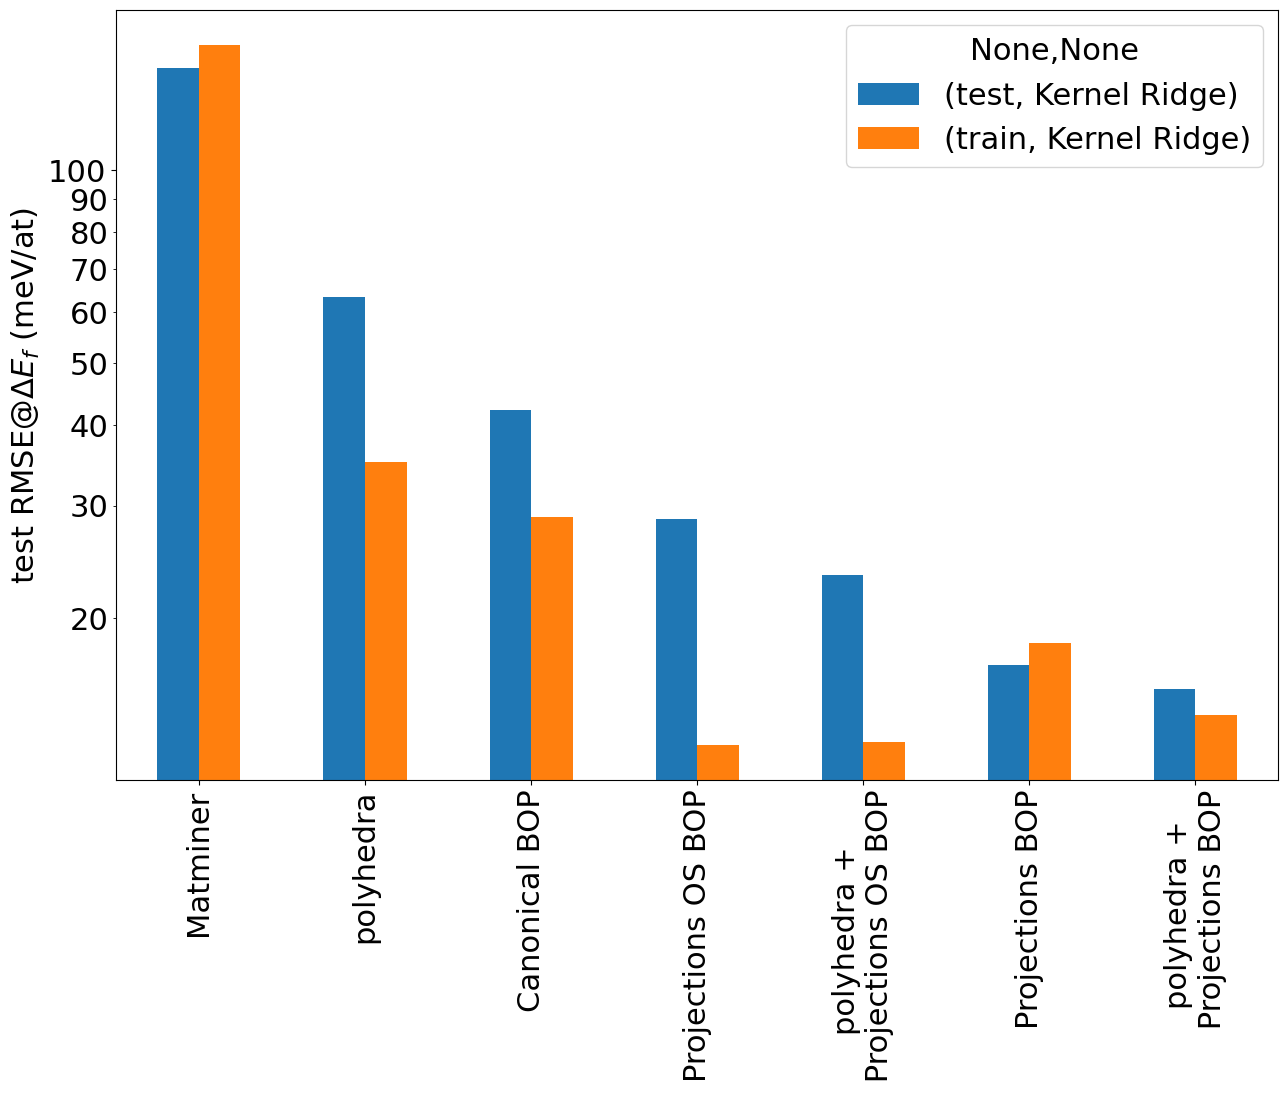

In [79]:
plot_best_scores = SourceFileLoader('plot_best_scores', 'Tools/DatasetTools/MLConveniences.py').load_module().plot_best_scores

ax = plot_best_scores(OptimalFittedScores)
ax.tick_params(axis='y', which = 'minor')
ax.yaxis.set_minor_formatter(FormatStrFormatter("%.0f"))
ax.yaxis.set_major_formatter(FormatStrFormatter("%.0f"))